In [1]:
import sys, session_info
import scanpy as sc, anndata as ad
import liana as li
import pandas as pd
import numpy as np
from liana.plotting._circle_plot import circle_plot  # debe importar sin error

In [2]:
adata = sc.read_h5ad('/home/mdiaz/HCC_project/MERGED_adata/scvi_integrated.h5ad')
adata

AnnData object with n_obs × n_vars = 159925 × 19916
    obs: 'Patient', 'DX', 'Sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'doublet', 'CellType', 'Batch', 'predicted', 'transfer_score', 'dataset', 'CellType_harmonized', 'leiden_r3'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_r3', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [3]:
adata.raw = ad.AnnData(
    X=adata.layers["counts"].copy(),
    var=adata.var.copy(),
    obs=adata.obs.copy()
)

In [4]:
adata.raw.X


<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 197085520 stored elements and shape (159925, 19916)>

In [5]:
# import liana's rank_aggregate
from liana.mt import rank_aggregate

In [6]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [7]:
adata

AnnData object with n_obs × n_vars = 159925 × 19916
    obs: 'Patient', 'DX', 'Sample', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', '_scvi_batch', '_scvi_labels', 'doublet', 'CellType', 'Batch', 'predicted', 'transfer_score', 'dataset', 'CellType_harmonized', 'leiden_r3'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_r3', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

# RRA

In [8]:
sorted(adata.obs.CellType_harmonized.unique())

['B cells',
 'Basophils',
 'CAF',
 'CDCs',
 'Cholangiocytes',
 'Endothelial cells',
 'Fibroblasts',
 'Hep',
 'Hepatocytes',
 'Macrophages',
 'Malignant_cells',
 'Monocytes',
 'NK cells',
 'NK-TR-CD160',
 'Neutrophils',
 'Plasma cells',
 'T cells',
 'TAMs',
 'TECs',
 'cDCs',
 'pDCs']

In [9]:
adata.obs["CellType_harmonized"] = (
    adata.obs["CellType_harmonized"]
    .replace({"cDCs": "CDCs"})
)

/tmp/ipykernel_2576061/4020185830.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [10]:
adata.obs["CellType_harmonized"] = (
    adata.obs["CellType_harmonized"]
    .replace({"Malignant_cells": "Malignant cells"})
)

/tmp/ipykernel_2576061/2986514881.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [11]:
adata.obs["CellType_harmonized"] = (
    adata.obs["CellType_harmonized"]
    .replace({"Hep": "Hepatocytes"})
)

/tmp/ipykernel_2576061/276823119.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [15]:
sorted(adata.obs.CellType_harmonized.unique())

# ===== LIANA Rank Aggregate (RRA) - Consenso de 4 métodos =====
import os, numpy as np, pandas as pd
import liana as li
import matplotlib.pyplot as plt
import scipy.sparse as sp

# ---------- 0) Chequeos básicos ----------
assert 'CellType_harmonized' in adata.obs.columns, "Falta adata.obs['CellType_harmonized']"

# Labels solicitados (sin mapeo canónico)
SOURCE_LABELS_REQ = ['Malignant cells', 'TAMs', 'TECs', 'Hepatocytes']
TARGET_LABELS_REQ = ['B cells','Basophils','CAF','Hepatocytes','Macrophages','Malignant cells', 'Cholangiocytes', 'Endothelial cells'
                     'NK-TR-CD160','Neutrophils','T cells','TAMs','TECs','CDCs', 'Fibroblasts']

OUTDIR = "/home/mdiaz/HCC_project/HCC_analysis/MERGED_analysis/liana_consensus"
os.makedirs(OUTDIR, exist_ok=True)

# ---------- 1) Normalización (CP10k + log1p) desde counts crudos ----------
import numpy as np
import scipy.sparse as sp

X_counts = adata.layers['counts'] if 'counts' in adata.layers else adata.X

if sp.issparse(X_counts):
    X_counts = X_counts.tocsr(copy=False)        # <- asegurar CSR
    lib = np.asarray(X_counts.sum(axis=1)).ravel()
    scale_vec = (1e4 / np.clip(lib, 1, None)).astype(np.float32)

    norm = X_counts.multiply(scale_vec[:, None]).tocsr(copy=False)
    norm = norm.astype(np.float32)               # ahorrar memoria
    norm.data = np.log1p(norm.data)              # log1p solo sobre los no-ceros

    X_lognorm = norm                             # CSR
else:
    lib = X_counts.sum(axis=1)
    norm = X_counts * ((1e4 / np.clip(lib, 1, None))[:, None])
    X_lognorm = np.log1p(norm).astype(np.float32)  # denso

adata.layers['log1p'] = X_lognorm                # ahora es CSR/CSC o ndarray soportado


# ===================== LIANA RRA personalizado (4 métodos) =====================
import os, numpy as np, pandas as pd
import scipy.sparse as sp
import liana as li
from liana.method import cellchat, cellphonedb, singlecellsignalr, natmi
import matplotlib.pyplot as plt

OUTDIR = "/home/mdiaz/HCC_project/HCC_analysis/MERGED_analysis/liana_consensus"
os.makedirs(OUTDIR, exist_ok=True)

# ---------- 0) Normalización (CP10k + log1p) a layer 'log1p' ----------
X_counts = adata.layers['counts'] if 'counts' in adata.layers else adata.X
if sp.issparse(X_counts):
    Xc = X_counts.tocsr(copy=False)
    lib = np.asarray(Xc.sum(axis=1)).ravel()
    scale_vec = (1e4 / np.clip(lib, 1, None)).astype(np.float32)
    norm = Xc.multiply(scale_vec[:, None]).tocsr(copy=False).astype(np.float32)
    norm.data = np.log1p(norm.data)  # log1p sobre nnz
    adata.layers['log1p'] = norm
else:
    lib = X_counts.sum(axis=1)
    norm = X_counts * ((1e4 / np.clip(lib, 1, None))[:, None])
    adata.layers['log1p'] = np.log1p(norm).astype(np.float32)

# ---------- 1) Definir los pares a evaluar (sin mapeos) ----------
SOURCE_LABELS_REQ = ['Malignant cells', 'TAMs', 'TECs', 'Hepatocytes']
TARGET_LABELS_REQ = ['B cells','Basophil','CAF','Hepatocytes','Macrophages','Malignant cells', 'Cholangiocytes', 'Endothelial cells'
                     'NK-TR-CD160','Neutrophils','T cells','TAMs','TECs','CDCs', 'Fibroblasts']

obs_labels = set(adata.obs['CellType_harmonized'].astype(str).unique())
src = [s for s in SOURCE_LABELS_REQ if s in obs_labels]
tgt = [t for t in TARGET_LABELS_REQ if t in obs_labels]

if not src or not tgt:
    print("[Aviso] Algunas etiquetas no existen en CellType_harmonized; se usarán únicamente las presentes.")
groupby_pairs = pd.DataFrame([(s, t) for s in src for t in tgt], columns=['source','target'])

# ---------- 2) Construir el agregador con los 4 métodos deseados ----------
custom_rra = li.mt.AggregateClass(li.mt.aggregate_meta,
                                  methods=[cellchat, cellphonedb, singlecellsignalr, natmi])

# ---------- 3) Ejecutar el consenso (RRA) ----------
np.random.seed(0)
custom_rra(
    adata=adata,
    groupby='CellType_harmonized',
    resource_name='consensus',
    expr_prop=0.1,
    groupby_pairs=groupby_pairs if not groupby_pairs.empty else None,
    # computación
    n_perms=1000,          # aplica a métodos permutacionales (e.g., CPDB)
    n_jobs=1,              # sube si quieres paralelizar
    seed=1337,
    # capa de expresión
    use_raw=False,
    layer='log1p',
    verbose=True,
    key_added='liana_res',
)

groupby = 'CellType_harmonized'       # tu columna
layer_for_props = 'counts'  # usa counts crudos para proporciones; caerá a X si no existe

res = adata.uns['liana_res'].copy()

# Detectar columnas de genes (fallback a *_complex si no están)
lig_col = 'ligand'  if 'ligand'  in res.columns else ('ligand_complex'  if 'ligand_complex'  in res.columns else None)
rec_col = 'receptor' if 'receptor' in res.columns else ('receptor_complex' if 'receptor_complex' in res.columns else None)
if lig_col is None or rec_col is None:
    raise ValueError("No encuentro columnas de ligando/receptor en liana_res (ligand/ligand_complex, receptor/receptor_complex).")

# Szzzzi ya existen props, no hacemos nada
need_lig = 'ligand_props'   not in res.columns
need_rec = 'receptor_props' not in res.columns
if not (need_lig or need_rec):
    print("[INFO] ligand_props / receptor_props ya existen en liana_res.")
else:
    # Si vienen complejos tipo 'B2M_FCGRT', toma el primer gen como aproximación
    def pick_gene(x):
        x = str(x)
        return x.split('_')[0] if '_' in x else x

    res['_lig_gene'] = res[lig_col].astype(str).map(pick_gene)
    res['_rec_gene'] = res[rec_col].astype(str).map(pick_gene)

    # Genes necesarios que estén realmente en var_names
    varnames = adata.var_names.astype(str)
    genes_needed = sorted(set(res['_lig_gene']).union(res['_rec_gene']))
    genes_in = [g for g in genes_needed if g in varnames.values]
    if not genes_in:
        # Si no hay ninguno en var_names, crea props=0.0 y continúa
        if need_lig: res['ligand_props'] = 0.0
        if need_rec: res['receptor_props'] = 0.0
    else:
        gene_to_idx = {g: int(np.where(varnames == g)[0][0]) for g in genes_in}

        # Matriz para props
        X = adata.layers[layer_for_props] if layer_for_props in adata.layers else adata.X
        is_sp = sp.issparse(X)

        # Tipos celulares que realmente aparecen
        CellType_harmonizeds_needed = pd.unique(
            pd.concat([res['source'].astype(str), res['target'].astype(str)], ignore_index=True)
        ).tolist()

        # Calcular proporción por (CellType_harmonized, gene): frac de células con expresión > 0
        props_records = []
        obs_group = adata.obs[groupby].astype(str).values

        gene_idx = np.array([gene_to_idx[g] for g in genes_in], dtype=int)
        for ct in CellType_harmonizeds_needed:
            cells_idx = np.where(obs_group == ct)[0]
            if cells_idx.size == 0:
                continue
            if is_sp:
                sub = X[cells_idx, :][:, gene_idx].tocsr(copy=False)
                nnz = (sub > 0).sum(axis=0)
                nnz = np.asarray(nnz).ravel()
            else:
                sub = X[np.ix_(cells_idx, gene_idx)]
                nnz = (sub > 0).sum(axis=0)
            frac = (nnz / float(cells_idx.size)).astype(float)
            for g, p in zip(genes_in, frac):
                props_records.append((ct, g, p))

        props_df = pd.DataFrame(props_records, columns=['CellType_harmonized','gene','prop'])

        # Merge a res para crear ligand_props / receptor_props
        if need_lig:
            lig = props_df.rename(columns={'CellType_harmonized':'source', 'gene':'_lig_gene', 'prop':'ligand_props'})
            res = res.merge(lig, on=['source','_lig_gene'], how='left')
        if need_rec:
            rec = props_df.rename(columns={'CellType_harmonized':'target', 'gene':'_rec_gene', 'prop':'receptor_props'})
            res = res.merge(rec, on=['target','_rec_gene'], how='left')

        # Rellenar faltantes con 0.0
        if need_lig: res['ligand_props']   = pd.to_numeric(res['ligand_props'], errors='coerce').fillna(0.0)
        if need_rec: res['receptor_props'] = pd.to_numeric(res['receptor_props'], errors='coerce').fillna(0.0)

    # Limpieza columnas temporales
    res.drop(columns=[c for c in ['_lig_gene','_rec_gene'] if c in res.columns], inplace=True)

# ==== continuar con tu flujo: filtro por props, métricas y plots ====
for c in ['magnitude_rank','specificity_rank','rank']:
    if c in res.columns:
        res[c] = pd.to_numeric(res[c], errors='coerce')

res_f = res[(res['ligand_props'] >= 0.10) & (res['receptor_props'] >= 0.10)].copy()

# ranks pequeños = mejor → transformar a "scores" para visualizar
if 'magnitude_rank' not in res_f.columns:
    res_f['magnitude_rank'] = res_f['rank']
if 'specificity_rank' not in res_f.columns:
    res_f['specificity_rank'] = res_f['rank']

res_f['consensus_mag']  = 1.0 - res_f['magnitude_rank']
res_f['consensus_spec'] = 1.0 - res_f['specificity_rank']

adata.uns['liana_res'] = res_f  # dejamos lista la tabla para li.pl.*
print("[OK] Props agregadas y filtro aplicado. Filas finales:", res_f.shape[0])


# === QA actualizado (sin exigir 'rank') ===
import os, json, numpy as np, pandas as pd

OUTDIR = "/home/mdiaz/HCC_project/HCC_analysis/MERGED_analysis/liana_consensus"
df = adata.uns['liana_res'].copy()

need_any_lig = ['ligand','ligand_complex']
need_any_rec = ['receptor','receptor_complex']
need_cols    = ['source','target','ligand_props','receptor_props','magnitude_rank','specificity_rank']

missing = [c for c in need_cols if c not in df.columns]
assert not missing, f"Faltan columnas: {missing}"
assert any(c in df.columns for c in need_any_lig), "Falta ligand/ligand_complex"
assert any(c in df.columns for c in need_any_rec), "Falta receptor/receptor_complex"

def check_01(col):
    v = pd.to_numeric(df[col], errors='coerce')
    na = int(v.isna().sum()); v = v.dropna()
    mn, mx = float(v.min()), float(v.max())
    assert 0.0 - 1e-9 <= mn <= 1.0 + 1e-9 and 0.0 - 1e-9 <= mx <= 1.0 + 1e-9, \
        f"{col} fuera de [0,1]: min={mn}, max={mx}"

for col in ['ligand_props','receptor_props','magnitude_rank','specificity_rank']:
    check_01(col)

summary = {
    'rows': int(df.shape[0]),
    'magnitude_rank_min': float(pd.to_numeric(df['magnitude_rank']).min()),
    'magnitude_rank_max': float(pd.to_numeric(df['magnitude_rank']).max()),
    'specificity_rank_min': float(pd.to_numeric(df['specificity_rank']).min()),
    'specificity_rank_max': float(pd.to_numeric(df['specificity_rank']).max()),
}
os.makedirs(OUTDIR, exist_ok=True)
with open(os.path.join(OUTDIR, "QA_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("QA OK"); summary


# === Top-K sin 'rank' ===
lr_cols = [c for c in ['ligand','ligand_complex'] if c in df.columns] + \
          [c for c in ['receptor','receptor_complex'] if c in df.columns]

top_global = df.sort_values(
    ['magnitude_rank','specificity_rank'], ascending=[True, True]
).head(15)
display(top_global[['source','target'] + lr_cols + ['magnitude_rank','specificity_rank',
                                                    'ligand_props','receptor_props']])

for s in ['Malignant','TAMs','TECs','Hepatocytes']:
    sub = df[df['source'] == s]
    if not sub.empty:
        print(f"\nTop 10 de {s} → *")
        display(sub.sort_values(['magnitude_rank','specificity_rank'],
                                ascending=[True, True]).head(10)
                [['target'] + lr_cols + ['magnitude_rank','specificity_rank']])


import liana as li
REQ_SRC = ['Malignant cells', 'TAMs', 'TECs', 'Hepatocytes']
REQ_TGT = ['B cells','Basophil','CAF','Hepatocytes','Macrophages','Malignant cells', 'Cholangiocytes', 'Endothelial cells'
                     'NK-TR-CD160','Neutrophils','T cells','TAMs','TECs','CDCs', 'Fibroblasts']

present_src = sorted(df['source'].astype(str).unique())
present_tgt = sorted(df['target'].astype(str).unique())
SRC_USE = [s for s in REQ_SRC if s in present_src] or present_src
TGT_USE = [t for t in REQ_TGT if t in present_tgt] or present_tgt

li.pl.dotplot(
    adata=adata, colour='magnitude_rank', size='specificity_rank',
    inverse_size=True, inverse_colour=True,
    source_labels=SRC_USE, target_labels=TGT_USE,
    top_n=10, orderby='magnitude_rank', orderby_ascending=True,
    figure_size=(12, 7), uns_key='liana_res',
    filter_fun=lambda x: (x['ligand_props'] >= 0.10) and (x['receptor_props'] >= 0.10),
)


import numpy as np, pandas as pd, liana as li
from IPython.display import display

uns_key = 'liana_res'
df = adata.uns[uns_key].copy()

# Columnas L/R (acepta 'ligand'/'receptor' o '*_complex')
L = 'ligand_complex'  if 'ligand_complex'  in df.columns else 'ligand'
R = 'receptor_complex' if 'receptor_complex' in df.columns else 'receptor'

# ---------- Top-K por source ----------
sources_focus = ['Malignant cells','TAMs','TECs','Hepatocytes']
top_k = 10

tops = []
for s in sources_focus:
    sub = df[df['source'] == s].sort_values(
        ['magnitude_rank','specificity_rank'], ascending=[True, True]
    ).head(top_k)
    if not sub.empty:
        tops.append(sub[['source','target',L,R]])
tops = pd.concat(tops, ignore_index=True) if tops else pd.DataFrame(columns=['source','target',L,R])

# Conjunto clave para el filtro
top_keys = set(map(tuple, tops[['source','target',L,R]].values))

def flt_top(r):
    # arma la tupla con las columnas presentes
    return (r['source'], r['target'], r.get(L, None), r.get(R, None)) in top_keys

# Etiquetas presentes para no fallar
present_src = [s for s in sources_focus if s in df['source'].astype(str).unique()]
present_tgt = sorted(df['target'].astype(str).unique())

# ---------- Dotplot ----------
p = li.pl.dotplot(
    adata=adata,
    colour='magnitude_rank',   # menor = mejor
    size='specificity_rank',   # menor = mejor
    inverse_colour=True,       # invertir ambos para que “mejor” = más intenso / más grande
    inverse_size=True,
    source_labels=present_src,
    target_labels=present_tgt,
    figure_size=(10, 12),
    top_n=None,                # no seleccionar por top_n; ya filtramos nosotros
    orderby=None,              # idem
    filter_fun=flt_top,
    uns_key=uns_key,
)
display(p)
p.save("/home/mdiaz/HCC_project/MERGED_analysis/figures/bubble_topK_sources_dotplot.png", dpi=300, width=11, height=7)


df = adata.uns['liana_res']
df['source'].value_counts()


### Utilizando el promedio

import numpy as np, pandas as pd, matplotlib.pyplot as plt

df = adata.uns['liana_res'].copy()
L = 'ligand_complex'  if 'ligand_complex'  in df.columns else 'ligand'
R = 'receptor_complex' if 'receptor_complex' in df.columns else 'receptor'

df['score'] = 1 - pd.to_numeric(df['magnitude_rank'])
df['spec']  = 1 - pd.to_numeric(df['specificity_rank'])
df = df[(df['ligand_props']>=0.10) & (df['receptor_props']>=0.10)].copy()

mat_counts = df.groupby(['source','target']).size().unstack(fill_value=0)
mat_mean   = (df.assign(w=lambda x: x['score']*x['spec'])
                .groupby(['source','target'])['w']
                .mean().unstack(fill_value=0))

fig, ax = plt.subplots(1,2, figsize=(14,5))
im0 = ax[0].imshow(mat_counts.values, aspect='auto'); ax[0].set_title('Number of interactions')
ax[0].set_yticks(range(mat_counts.shape[0])); ax[0].set_yticklabels(mat_counts.index, fontsize=8)
ax[0].set_xticks(range(mat_counts.shape[1])); ax[0].set_xticklabels(mat_counts.columns, rotation=90, fontsize=8)
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(mat_mean.values, aspect='auto'); ax[1].set_title('Magnitude per Specificity rank')
ax[1].set_yticks(range(mat_mean.shape[0])); ax[1].set_yticklabels(mat_mean.index, fontsize=8)
ax[1].set_xticks(range(mat_mean.shape[1])); ax[1].set_xticklabels(mat_mean.columns, rotation=90, fontsize=8)
plt.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()


### Utilizando z-score

import numpy as np, pandas as pd, matplotlib.pyplot as plt

df = adata.uns['liana_res'].copy()
L = 'ligand_complex'  if 'ligand_complex'  in df.columns else 'ligand'
R = 'receptor_complex' if 'receptor_complex' in df.columns else 'receptor'

df['score'] = 1 - pd.to_numeric(df['magnitude_rank'])
df['spec']  = 1 - pd.to_numeric(df['specificity_rank'])
df = df[(df['ligand_props']>=0.10) & (df['receptor_props']>=0.10)].copy()

mat_counts = df.groupby(['source','target']).size().unstack(fill_value=0)
mat_sum = (df.assign(w=lambda x: x['score']*x['spec'])
             .groupby(['source','target'])['w'].sum().unstack(fill_value=0))
mat_z = (mat_sum.T - mat_sum.mean(axis=1)) / (mat_sum.std(axis=1)+1e-9); mat_z = mat_z.T

fig, ax = plt.subplots(1,2, figsize=(14,5))
im0 = ax[0].imshow(mat_sum.values, aspect='auto'); ax[0].set_title('Number of interactions')
ax[0].set_yticks(range(mat_sum.shape[0])); ax[0].set_yticklabels(mat_sum.index, fontsize=8)
ax[0].set_xticks(range(mat_sum.shape[1])); ax[0].set_xticklabels(mat_sum.columns, rotation=90, fontsize=8)
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(mat_z.values, aspect='auto'); ax[1].set_title('Magnitude per Specificity rank')
ax[1].set_yticks(range(mat_z.shape[0])); ax[1].set_yticklabels(mat_z.index, fontsize=8)
ax[1].set_xticks(range(mat_z.shape[1])); ax[1].set_xticklabels(mat_z.columns, rotation=90, fontsize=8)
plt.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()

from plotnine import ggplot, aes, geom_col, coord_flip, theme_bw, labs, theme, element_text

def top_lr_by_source(df, source, k=15):
    d = (df[df['source']==source].copy()
           .assign(composite=lambda x: (1-x['magnitude_rank'])*(1-x['specificity_rank']))
           .sort_values('composite', ascending=False))
    d['pair'] = d[L] + ' -> ' + d[R]
    d = d.groupby('pair', as_index=False)['composite'].max().head(k)
    return d

for s in ['Hepatocytes','Malignant cells','TAMs','TECs']:
    d = top_lr_by_source(df, s, k=15)
    if d.empty: continue
    p = (ggplot(d, aes('reorder(pair, composite)', 'composite'))
         + geom_col() + coord_flip() + theme_bw()
         + labs(title=f"Top L–R salientes de {s}", x="Ligando -> Receptor", y="Composite (score×spec)")
         + theme(axis_text_y=element_text(size=8)))
    display(p)
    print(p)

import os

output_dir = "/home/mdiaz/HCC_project/MERGED_analysis/figures/"
os.makedirs(output_dir, exist_ok=True)

for s in ['Hepatocytes','Malignant cells','TAMs','TECs']:
    d = top_lr_by_source(df, s, k=15)
    if d.empty:
        continue

    p = (ggplot(d, aes('reorder(pair, composite)', 'composite'))
         + geom_col()
         + coord_flip()
         + theme_bw()
         + labs(title=f"Top L–R salientes de {s}",
                x="Ligando -> Receptor",
                y="Composite (score×spec)")
         + theme(axis_text_y=element_text(size=8)))

    # Guardar como PDF
    p.save(
        filename=f"{output_dir}/Top_LR_{s}.pdf",
        format="pdf",
        width=8,
        height=6,
        units="in",
        dpi=300
    )


## RRA todos contra todos

import liana as li
from liana.method import cellchat, cellphonedb, singlecellsignalr, natmi
import numpy as np, pandas as pd

# 1) Agregador con los 4 métodos
custom_rra = li.mt.AggregateClass(li.mt.aggregate_meta,
                                  methods=[cellchat, cellphonedb, singlecellsignalr, natmi])

# 2) Ejecutar SIN restricción de pares
np.random.seed(1337)
custom_rra(
    adata=adata,
    groupby='CellType_harmonized',
    resource_name='consensus',
    expr_prop=0.1,
    groupby_pairs=None,   # ← clave: evaluar todos vs todos
    n_perms=1000,
    n_jobs=1,
    seed=1337,
    use_raw=False,
    layer=None,        # la capa normalizada que ya creaste
    verbose=True,
    key_added='liana_res',
)

# 3) (Solo si faltan) volver a añadir ligand_props / receptor_props
res = adata.uns['liana_res'].copy()
import numpy as np, pandas as pd, scipy.sparse as sp

def _get_counts_matrix(adata, layer_counts='counts'):
    if layer_counts in getattr(adata, 'layers', {}):
        X = adata.layers[layer_counts]
    else:
        X = adata.X
    return X, sp.issparse(X)

def _split_complex(x: str):
    x = str(x)
    # LIANA suele usar '_' para subunidades; añadimos separadores comunes de forma segura
    for sep in ['_', '+', '&']:
        if sep in x:
            return [p for p in x.split(sep) if p]
    return [x]

def _props_by_group(adata, genes, groupby, layer_counts='counts', expr_cutoff=0):
    X, is_sp = _get_counts_matrix(adata, layer_counts)
    obs_group = adata.obs[groupby].astype(str).values
    varnames = adata.var_names.astype(str)
    idx_map = {g: np.where(varnames == g)[0][0] for g in genes if g in varnames.values}

    rows = []
    for ct in np.unique(obs_group):
        I = np.where(obs_group == ct)[0]
        if I.size == 0 or len(idx_map) == 0:
            continue
        cols = list(idx_map.values())
        if is_sp:
            sub = X[I, :][:, cols].tocsr()
            nnz = (sub > expr_cutoff).sum(axis=0).A1
        else:
            sub = X[np.ix_(I, cols)]
            nnz = (sub > expr_cutoff).sum(axis=0)
        prop = nnz.astype(float) / float(I.size)
        rows.extend([(ct, g, p) for g, p in zip(idx_map.keys(), prop)])
    return pd.DataFrame(rows, columns=['CellType_harmonized', 'gene', 'prop'])

# --- construir props para ligandos y receptores (res respeta complejos) ---
res = adata.uns['liana_res'].copy()

L = 'ligand_complex'   if 'ligand_complex'   in res.columns else 'ligand'
R = 'receptor_complex' if 'receptor_complex' in res.columns else 'receptor'

# universo de subunidades necesarias
lig_subunits = sorted({s for v in res[L].astype(str).unique() for s in _split_complex(v)})
rec_subunits = sorted({s for v in res[R].astype(str).unique() for s in _split_complex(v)})
genes_needed = sorted(set(lig_subunits) | set(rec_subunits))

# props por gen y por cell type (sobre capa de cuentas, no log1p)
props_df = _props_by_group(adata, genes_needed, groupby='CellType_harmonized', layer_counts='counts', expr_cutoff=0)

# helper: prop de un complejo = min de sus subunidades (si falta alguna, 0.0)
def _complex_prop(CellType_harmonized, comp):
    subs = _split_complex(comp)
    sub_df = props_df[(props_df.CellType_harmonized == CellType_harmonized) & (props_df.gene.isin(subs))]
    if sub_df.shape[0] < len(subs):
        return 0.0
    return float(sub_df['prop'].min())

# calcular ligand_props y receptor_props
def _annotate_props(res, side_col, ct_col, out_col):
    rows = []
    for ct, comp in zip(res[ct_col].astype(str), res[side_col].astype(str)):
        rows.append(_complex_prop(ct, comp))
    res[out_col] = pd.to_numeric(rows)
    return res

res = _annotate_props(res, L, 'source', 'ligand_props')
res = _annotate_props(res, R, 'target', 'receptor_props')

adata.uns['liana_res'] = res


# 4) Filtro estándar y recomputa el heatmap “todos vs todos”
df = adata.uns['liana_res'].copy()
df = df[(pd.to_numeric(df['ligand_props'],errors='coerce')>=0.10) &
        (pd.to_numeric(df['receptor_props'],errors='coerce')>=0.10)].copy()
df['score'] = 1 - pd.to_numeric(df['magnitude_rank'], errors='coerce')
df['spec']  = 1 - pd.to_numeric(df['specificity_rank'], errors='coerce')
df['w']     = df['score']*df['spec']

ct_all = (list(adata.obs['CellType_harmonized'].cat.categories.astype(str))
          if pd.api.types.is_categorical_dtype(adata.obs['CellType_harmonized'])
          else sorted(adata.obs['CellType_harmonized'].astype(str).unique()))

mat_counts = (df.groupby(['source','target']).size()
                .unstack(fill_value=0)
                .reindex(index=ct_all, columns=ct_all, fill_value=0))

mat_sum = (df.groupby(['source','target'])['w'].sum()
             .unstack(fill_value=0)
             .reindex(index=ct_all, columns=ct_all, fill_value=0))


import pandas as pd, numpy as np

df = adata.uns['liana_res'].copy()
L = 'ligand_complex' if 'ligand_complex' in df.columns else 'ligand'
R = 'receptor_complex' if 'receptor_complex' in df.columns else 'receptor'

# 1) columnas y rangos
req = {'source','target','magnitude_rank','specificity_rank','ligand_props','receptor_props',L,R}
missing = [c for c in req if c not in df.columns]
print("Faltan columnas:", missing)
print(df[['magnitude_rank','specificity_rank','ligand_props','receptor_props']].describe())

# 2) complejos realmente más restrictivos
is_complex = df[L].astype(str).str.contains(r'[_+&]') | df[R].astype(str).str.contains(r'[_+&]')
if is_complex.any():
    print("Q de props en COMPLEJOS (ligando):", df.loc[df[L].str.contains(r'[_+&]'),'ligand_props'].quantile([.1,.5,.9]).to_dict())
    print("Q de props en COMPLEJOS (receptor):", df.loc[df[R].str.contains(r'[_+&]'),'receptor_props'].quantile([.1,.5,.9]).to_dict())

# 3) núcleo robusto (paper-like)
core = df[(df['ligand_props']>=0.10) & (df['receptor_props']>=0.10) & (df['magnitude_rank']<0.05)].copy()
print("Interacciones en núcleo robusto:", core.shape[0])

# 4) matrices todos-vs-todos (como tenías)
df2 = df[(df['ligand_props']>=0.10) & (df['receptor_props']>=0.10)].copy()
df2['score'] = 1 - pd.to_numeric(df2['magnitude_rank'], errors='coerce')
df2['spec']  = 1 - pd.to_numeric(df2['specificity_rank'], errors='coerce')
df2['w']     = df2['score']*df2['spec']

ct = (list(adata.obs['CellType_harmonized'].cat.categories.astype(str))
      if pd.api.types.is_categorical_dtype(adata.obs['CellType_harmonized'])
      else sorted(adata.obs['CellType_harmonized'].astype(str).unique()))

mat_counts = (df2.groupby(['source','target']).size()
                .unstack(fill_value=0).reindex(index=ct, columns=ct, fill_value=0))

mat_sum = (df2.groupby(['source','target'])['w'].sum()
             .unstack(fill_value=0).reindex(index=ct, columns=ct, fill_value=0))

print("mat_counts shape:", mat_counts.shape, "nonzero:", (mat_counts.values>0).sum())
print("mat_sum    shape:", mat_sum.shape, "sum(w):", float(mat_sum.values.sum()))

cols_show = [L,R,'source','target','magnitude_rank','specificity_rank','ligand_props','receptor_props']
display(core.sort_values('magnitude_rank').head(15)[cols_show])

top_by_src = (core.sort_values(['source','magnitude_rank'])
                  .groupby('source').head(10)[cols_show])


top_by_src

### Filtros por especificidad

dff = df[(df['ligand_props']>=0.10) & (df['receptor_props']>=0.10)].copy()
dff = dff[(dff['magnitude_rank'] < 0.05) & (dff['specificity_rank'] < 0.5)]
# si sigue muy denso: usa 0.02 ó 0.01 en magnitud, y 0.4 en especificidad
dff

### Mitigar “ubicuos” (opcional, si no son tu foco)

#Aplicar un filtro suave para housekeeping/MHC/ribosomales que tienden a “inundar”:

import re
L = 'ligand_complex' if 'ligand_complex' in dff.columns else 'ligand'
R = 'receptor_complex' if 'receptor_complex' in dff.columns else 'receptor'

# listas orientativas; ajústalas a tu criterio
BAN_L = {'B2M','ALB'}
BAN_R = set()  # normalmente no banearía receptores, salvo casos extremos

mask_bad = (
    dff[L].isin(BAN_L) |
    dff[L].str.match(r'RPS\d+|RPL\d+', na=False) |   # ribosomales
    dff[L].str.match(r'HLA-[ABC]', na=False)        # MHC-I clásicos
)
dff = dff[~mask_bad].copy()


### Ponderación y recortes para grafo

#- Refuerza la especificidad: w = (1 - magnitude_rank) * (1 - specificity_rank)**γ con γ=1.5–2.0.

#- Mantén top-K pares por emisor

dff['score'] = 1 - dff['magnitude_rank']
dff['spec']  = 1 - dff['specificity_rank']
gamma = 1.5
dff['w']     = dff['score'] * (dff['spec'] ** gamma)

# top-10 pares por 'source'
dff = (dff.sort_values(['source','w'], ascending=[True, False])
          .groupby('source').head(10))

df[(df[L].str.contains('HLA-E', na=False)) & (df[R].str.contains('KLRD1', na=False))]


dff

# Penalización selectiva (suave) a familias ubicuas (no excluir)

import re
L = 'ligand_complex' if 'ligand_complex' in dff.columns else 'ligand'

# Familias frecuentes: MHC-Ia (A/B/C), MHC-Ib (E/F/G), ribosomales
pat_mhc_ia = r'^(B2M|HLA-[ABC])$'
pat_mhc_ib = r'^HLA-[EFG]$'
pat_ribo   = r'^(RPS\d+|RPL\d+)$'

# Más suave con Ib que con Ia (ya excluiste A/B/C y B2M arriba, esto actúa por si algo quedó)
penal_ia = 0.6   # si aún conservas algo de Ia
penal_ib = 0.75  # penalización leve para E/F/G
penal_rb = 0.5

mask_ia = dff[L].str.match(pat_mhc_ia, na=False)
mask_ib = dff[L].str.match(pat_mhc_ib, na=False)
mask_rb = dff[L].str.match(pat_ribo,   na=False)

dff.loc[mask_ia, 'w'] *= penal_ia
dff.loc[mask_ib, 'w'] *= penal_ib
dff.loc[mask_rb, 'w'] *= penal_rb


# Umbral de especificidad condicional para familias ubicuas

# pides más especificidad si es MHC o ribosomal
spec_strict = 0.30  # p.ej. exigir specificity_rank < 0.30
keep = ~((mask_ia | mask_ib | mask_rb) & (dff['specificity_rank'] >= spec_strict))
dff = dff[keep].copy()


# “Soporte por método” (consenso explicable)

import pandas as pd
# columnas por método (ajusta a las que existan en tu df)
cols = {
    'cellchat_prob': ('lr_probs', 'high_better'),
    'cellchat_p':    ('cellchat_pvals', 'low_better'),
    'cpdb_mean':     ('lr_means', 'high_better'),
    'cpdb_p':        ('cellphone_pvals', 'low_better'),
    'natmi_score':   ('lrscore', 'high_better'),
    'scsr_exprprod': ('expr_prod', 'high_better'),
}

def norm_rank(s, direction):
    x = pd.to_numeric(s, errors='coerce')
    r = x.rank(method='average', ascending=(direction=='low_better'))
    r = (r - 1) / max(len(r) - 1, 1)
    return r

for name, (col, direction) in cols.items():
    if col in dff.columns:
        dff[name + '_rank'] = norm_rank(dff[col], direction)

rank_cols = [c for c in dff.columns if c.endswith('_rank')]
q = 0.10
if rank_cols:
    dff['method_support'] = (dff[rank_cols] < q).sum(axis=1)
    dff = dff[dff['method_support'] >= 2].copy()


# Jaccard Index (k-óptimo de interacciones)

import numpy as np, pandas as pd
from itertools import combinations

# ---------- Config ----------
# dff: DataFrame con tus interacciones ya filtradas (expr, magnitude, specificity, etc.)
# Orden principal para Top-K global:
ORDER_COL = 'w'  # usa 'w'; si no existe, usa 'score' (1 - magnitude_rank) o -'magnitude_rank'
ASC = False       # mayor w = mejor

# Paso y rango de K (ajusta si lo necesitas)
N = len(dff)
step = max(5, N // 100)       # ~100 puntos como máximo
Kmax = min(max(50, int(N*0.15)), 1500)  # por seguridad
K_grid = np.arange(step, min(Kmax, N)+1, step)

# ---------- Identificador único de interacción ----------
L = 'ligand_complex' if 'ligand_complex' in dff.columns else 'ligand'
R = 'receptor_complex' if 'receptor_complex' in dff.columns else 'receptor'
def make_edge_id(df):
    return (df['source'].astype(str) + '|' +
            df['target'].astype(str) + '|' +
            df[L].astype(str)       + '|' +
            df[R].astype(str))

dff = dff.copy()
dff['edge_id'] = make_edge_id(dff)

# Si no tienes 'w', construye uno básico:
if ORDER_COL not in dff.columns:
    dff['score'] = 1 - pd.to_numeric(dff['magnitude_rank'], errors='coerce')
    dff['spec']  = 1 - pd.to_numeric(dff['specificity_rank'], errors='coerce')
    dff['w']     = dff['score'] * dff['spec']
    ORDER_COL, ASC = 'w', False

dff_sorted = dff.sort_values(ORDER_COL, ascending=ASC).reset_index(drop=True)

def top_set(df_sorted, K):
    return set(df_sorted.loc[:K-1, 'edge_id'])

def jaccard(a, b):
    if not a and not b: return 1.0
    inter = len(a & b)
    union = len(a | b)
    return inter / union if union else 0.0

# ---------- (1) Estabilidad S(K) vs S(K-ΔK) ----------
delta = max(step, 10)  # ventana de comparación
Ks_stab, J_stab = [], []
S_prev_map = {}
for K in K_grid:
    S_K = top_set(dff_sorted, K)
    K_prev = K - delta
    if K_prev in S_prev_map:
        S_prev = S_prev_map[K_prev]
    else:
        S_prev = top_set(dff_sorted, max(step, K_prev)) if K_prev > 0 else set()
        S_prev_map[K_prev] = S_prev
    Ks_stab.append(K)
    J_stab.append(jaccard(S_K, S_prev))

stab_curve = pd.DataFrame({'K': Ks_stab, 'Jaccard_stability': J_stab})

# ---------- (2) Acuerdo entre métodos a Top-K ----------
# Columnas por método presentes en tu df (ajusta nombres si difieren en tu tabla):
method_specs = [
    ('cellchat_prob',  'lr_probs',         'high_better'),
    ('cellchat_p',     'cellchat_pvals',   'low_better'),
    ('cpdb_mean',      'lr_means',         'high_better'),
    ('cpdb_p',         'cellphone_pvals',  'low_better'),
    ('natmi_score',    'lrscore',          'high_better'),
    ('scsr_exprprod',  'expr_prod',        'high_better'),
]
avail = [(name,col,how) for (name,col,how) in method_specs if col in dff.columns]

def rank_series(s, how):
    x = pd.to_numeric(s, errors='coerce')
    # rango normalizado [0,1] (0 = top)
    r = x.rank(method='average', ascending=(how=='high_better')==False)
    return (r - 1) / max(len(r)-1, 1)

# Precomputar rangos por método disponible
rank_cols = []
for name, col, how in avail:
    rcol = f'{name}_rank'
    dff[rcol] = rank_series(dff[col], how)
    rank_cols.append(rcol)

def method_top_set(df, rcol, K):
    # 0 = mejor → tomamos los K menores
    idx = np.argsort(df[rcol].values)[:K]
    return set(df.iloc[idx]['edge_id'])

Ks_meth, J_mean, J_std = [], [], []
if len(rank_cols) >= 2:
    for K in K_grid:
        sets = [method_top_set(dff, rcol, K) for rcol in rank_cols]
        jvals = []
        for (A,B) in combinations(sets, 2):
            jvals.append(jaccard(A,B))
        Ks_meth.append(K)
        J_mean.append(float(np.mean(jvals)) if jvals else np.nan)
        J_std.append(float(np.std(jvals)) if jvals else np.nan)

method_curve = pd.DataFrame({'K': Ks_meth, 'Jaccard_methods_mean': J_mean, 'Jaccard_methods_sd': J_std})

# ---------- Selección automática de K* ----------
def knee_point(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    # Normaliza 0-1
    x_ = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_ = (y - y.min()) / (y.max() - y.min() + 1e-12)
    p1 = np.array([x_[0], y_[0]]); p2 = np.array([x_[-1], y_[-1]])
    v = p2 - p1; v /= (np.linalg.norm(v) + 1e-12)
    # Distancia perpendicular a la recta p1->p2
    d = np.abs((y_ - p1[1]) * v[0] - (x_ - p1[0]) * v[1])
    return int(x[np.argmax(d)])

K_star = None
if not method_curve.empty and method_curve['Jaccard_methods_mean'].notna().sum() >= 3:
    # “rodilla” del acuerdo entre métodos (preferida)
    valid = method_curve.dropna()
    K_star = knee_point(valid['K'].values, valid['Jaccard_methods_mean'].values)
else:
    # fallback: “rodilla” de estabilidad
    valid = stab_curve.dropna()
    K_star = knee_point(valid['K'].values, valid['Jaccard_stability'].values)

print("K* sugerido:", K_star)

# ---------- Subconjunto final a K* (global, por ORDER_COL) ----------
S_star = dff_sorted.loc[:K_star-1].copy() if K_star is not None else dff_sorted.copy()


import matplotlib.pyplot as plt

# 1) Estabilidad
plt.figure(figsize=(6,4))
plt.plot(stab_curve['K'], stab_curve['Jaccard_stability'])
plt.xlabel('Top K'); plt.ylabel('Índice de Jaccard'); plt.title('Estabilidad S(K) vs S(K-ΔK)')
plt.tight_layout(); plt.show()

# 2) Acuerdo entre métodos
if not method_curve.empty:
    plt.figure(figsize=(6,4))
    plt.plot(method_curve['K'], method_curve['Jaccard_methods_mean'])
    plt.xlabel('Top K'); plt.ylabel('Jaccard promedio (métodos)')
    plt.title('Acuerdo entre métodos vs K')
    plt.tight_layout(); plt.show()


### K-normalizada

# Suponiendo stab_curve y method_curve con las mismas K
dfk = (stab_curve.merge(method_curve, on='K', how='inner')
                 .dropna(subset=['Jaccard_stability','Jaccard_methods_mean']))
S = dfk['Jaccard_stability'].values
M = dfk['Jaccard_methods_mean'].values
H = 2 * (S*M) / (S+M + 1e-12)
K_star_comb = int(dfk.loc[H.argmax(), 'K'])
print("K* (combinado armónico):", K_star_comb)


# Producir y comparar subconjuntos finales

# Conjuntos finales
S_k45 = dff_sorted.head(45).copy()
S_k35 = dff_sorted.head(35).copy()

# Comparación
e45 = set(S_k45['edge_id']); e35 = set(S_k35['edge_id'])
print("Intersección:", len(e45 & e35), "Solo K=45:", len(e45 - e35), "Solo K=35:", len(e35 - e45))

# Cobertura por emisor
cov = (lambda S: S.groupby('source')['w'].sum() / dff.groupby('source')['w'].sum())
print("Cobertura media por source (K=35):", float(cov(S_k35).mean()))
print("Cobertura media por source (K=45):", float(cov(S_k45).mean()))

# Si tienes method_support:
for S, k in [(S_k35,35),(S_k45,45)]:
    if 'method_support' in S.columns:
        print(f"method_support medio K={k}:", float(S['method_support'].mean()))


# Doble chequeo de las 10 interacciones marginales (recomendado)

L = 'ligand_complex' if 'ligand_complex' in dff.columns else 'ligand'
R = 'receptor_complex' if 'receptor_complex' in dff.columns else 'receptor'
cols_show = [L, R, 'source', 'target', 'w', 'magnitude_rank', 'specificity_rank', 'method_support']

# conjuntos
S_k35 = dff_sorted.head(35).copy()
S_k45 = dff_sorted.head(45).copy()

e35 = set(S_k35['edge_id'])
extra = S_k45[~S_k45['edge_id'].isin(e35)].copy()   # las 10 marginales

# resumen de calidad
print("Extras n=", extra.shape[0])
print(extra[['specificity_rank','magnitude_rank','method_support']].describe())

# filtro mínimo sugerido para las 10 extras
extra_keep = extra[
    (extra.get('method_support', 0) >= 2) &
    (extra['specificity_rank'] < 0.50)
].copy()

print("Extras que pasan criterios:", extra_keep.shape[0])
display(extra_keep.sort_values('w', ascending=False)[cols_show])

# conjunto final “K45 curado”
final_k45 = pd.concat([S_k35, extra_keep], ignore_index=True).drop_duplicates('edge_id')
print("Tamaño final curado:", final_k45.shape[0])


# Eliminamos 3 interacciones poco específicas 

low = [
    ('EFNB2','PECAM1'),
    ('CLEC1B','KLRB1'),
    ('F8','ASGR2'),
]
L = 'ligand_complex' if 'ligand_complex' in dff.columns else 'ligand'
R = 'receptor_complex' if 'receptor_complex' in dff.columns else 'receptor'

def tag_conf(row):
    pair = (str(row[L]), str(row[R]))
    if pair in low:
        return 'low'
    # sólidas:
    solid = {('CXCL12','ACKR3'), ('MMRN2','CD93'), ('LAMA4','ITGA6_ITGB1')}
    if pair in solid:
        return 'high'
    # resto “media”
    return 'medium'

dff['confidence'] = dff.apply(tag_conf, axis=1)

# versión “K=45 curado” (excluye low)
final_k45 = dff.sort_values('w', ascending=False).head(45)
final_k45 = final_k45[final_k45['confidence']!='low'].copy()


# PLots

# Top 45

### Helpers

def _ensure_complex_cols(df):
    if 'ligand_complex' not in df.columns and 'ligand' in df.columns:
        df = df.rename(columns={'ligand':'ligand_complex'})
    if 'receptor_complex' not in df.columns and 'receptor' in df.columns:
        df = df.rename(columns={'receptor':'receptor_complex'})
    return df

def _make_numeric(df):
    num_cols = [
        'magnitude_rank','specificity_rank','ligand_props','receptor_props',
        'lr_means','lr_probs','lrscore','expr_prod','cellchat_pvals','cellphone_pvals','w'
    ]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    if 'w' not in df.columns and {'magnitude_rank','specificity_rank'} <= set(df.columns):
        df['score'] = 1 - df['magnitude_rank']
        df['spec']  = 1 - df['specificity_rank']
        df['w']     = df['score'] * df['spec']
    df = df.replace([np.inf,-np.inf], np.nan).dropna(subset=['ligand_props','receptor_props'])
    return df

def _pick_label_var(df):
    # Orden de preferencia (usa lo que exista en tu tabla)
    candidates = ['lr_means','lr_probs','lrscore','expr_prod','cellchat_pvals','cellphone_pvals','props']
    for c in candidates:
        if c in df.columns:
            return c
    # último recurso: usa 'props'
    return 'props'

def _pick_labels_from_df(df):
    present_sources = df['source'].astype(str).unique().tolist()
    present_targets = df['target'].astype(str).unique().tolist()
    prio = ['Malignant cells','TECs','TAMs','Hepatocytes','Macrophages']
    sources = [s for s in prio if s in present_sources] + [s for s in present_sources if s not in prio]
    targets = [t for t in prio if t in present_targets] + [t for t in present_targets if t not in prio]
    return sources, targets


Using resource `consensus`.
Using the `log1p` layer!
/home/mdiaz/miniconda3/envs/liana_kernel/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/mdiaz/miniconda3/envs/liana_kernel/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:150: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/home/mdiaz/miniconda3/envs/liana_kernel/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.23 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 122062 samples and 1376 features
Running CellChat


/home/mdiaz/miniconda3/envs/liana_kernel/lib/python3.11/site-packages/liana/method/_pipe_utils/_get_mean_perms.py:44: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  3%|▊                           | 31/1000 [03:24<1:45:57,  6.56s/it]

KeyboardInterrupt: 

# Tile plot

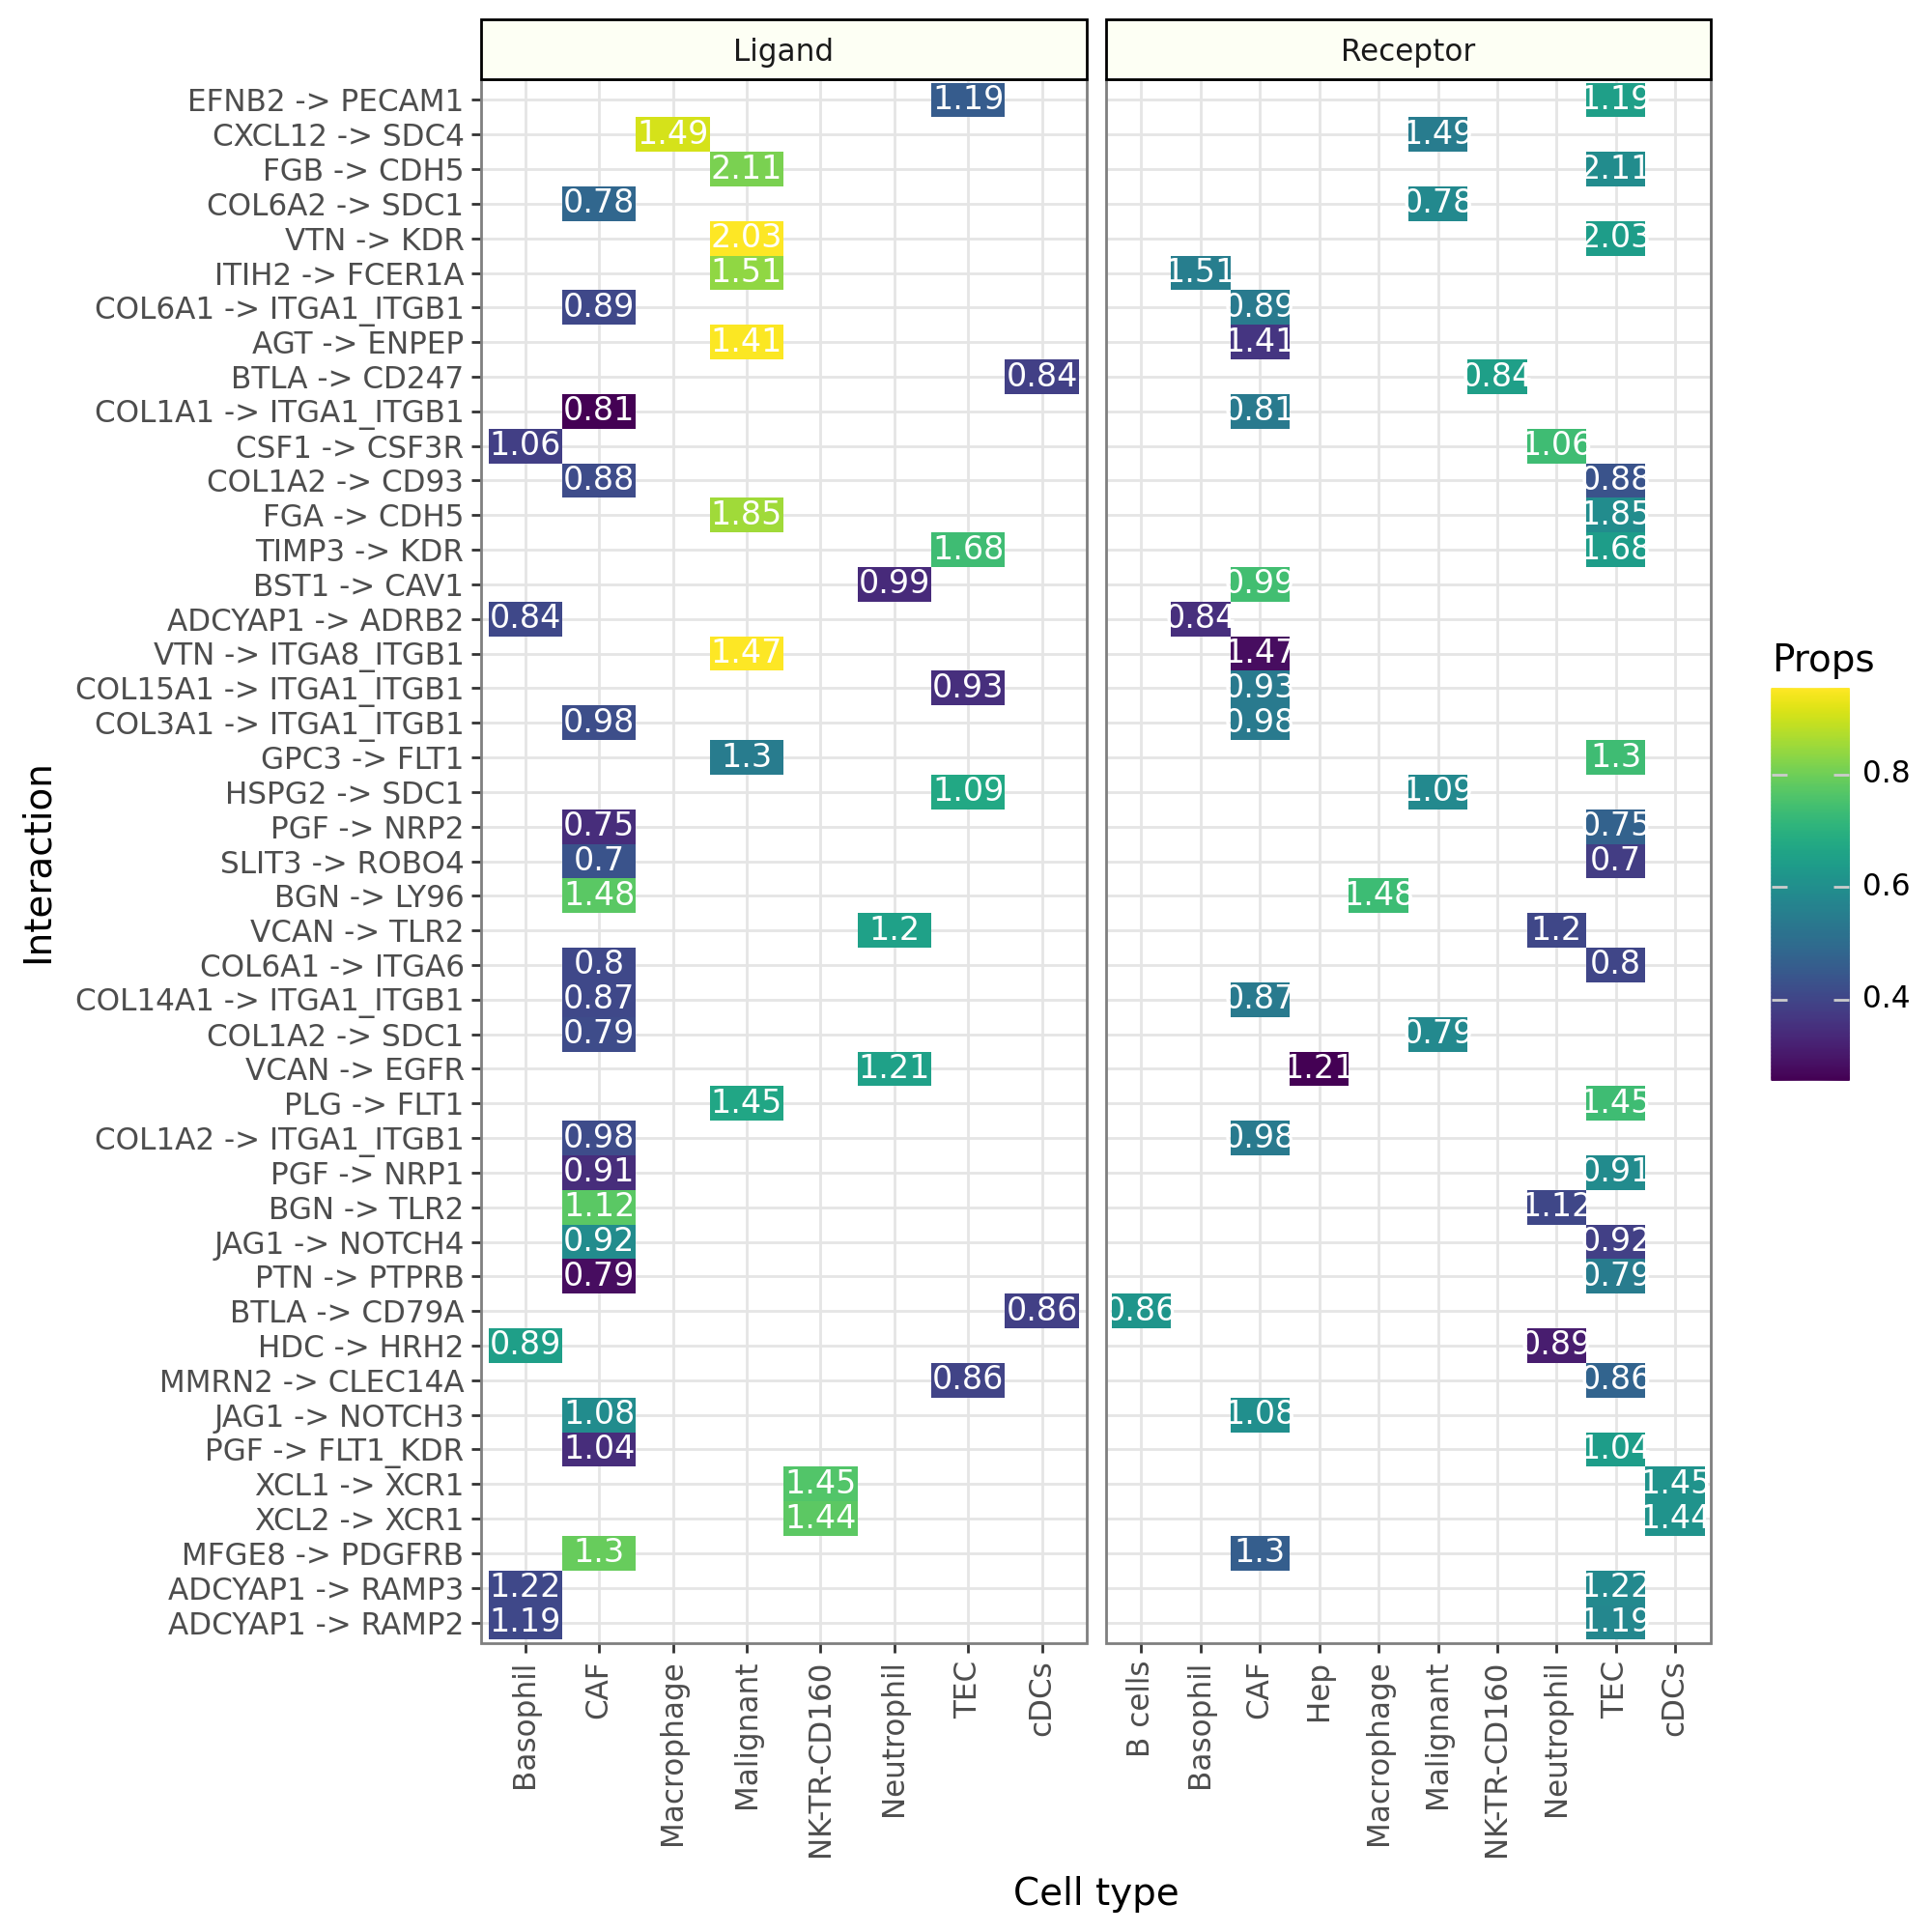

In [30]:
# 1) Construye TOP-K*
df_all = _make_numeric(adata.uns['liana_res'].copy())
df_all = _ensure_complex_cols(df_all)

K_star = 45  # o 35
df_top = df_all.sort_values('w', ascending=False).head(K_star).copy()

# 2) Labels presentes
sources, targets = _pick_labels_from_df(df_top)

# 3) Elegir label válido y su función (evitar strings si label==fill)
label_var = _pick_label_var(df_top)
label_fun = (lambda x: float(np.round(x, 2))) if label_var != 'props' else None
# Si label_var == 'props' y quieres texto, ¡NO! -> deja None o devuelve float.

# 4) Tileplot
my_plot = li.pl.tileplot(
    liana_res=df_top,
    fill='props',
    label=label_var,
    **({'label_fun': label_fun} if label_fun is not None else {}),
    top_n=df_top.shape[0],
    orderby='w', orderby_ascending=False,
    source_labels=sources, target_labels=targets,
    source_title='Ligand', target_title='Receptor',
    figure_size=(max(10, 0.55*len(targets)), max(10, 0.55*len(sources))),
)
my_plot


In [39]:
from pathlib import Path
outdir = Path("/home/mdiaz/HCC_project/MERGED_analysis/figures/"); outdir.mkdir(parents=True, exist_ok=True)
my_plot.save(outdir / f"tileplot_topK{K_star}.png", dpi=300, verbose=False)



# Más importantes en tipos celulares de interés 

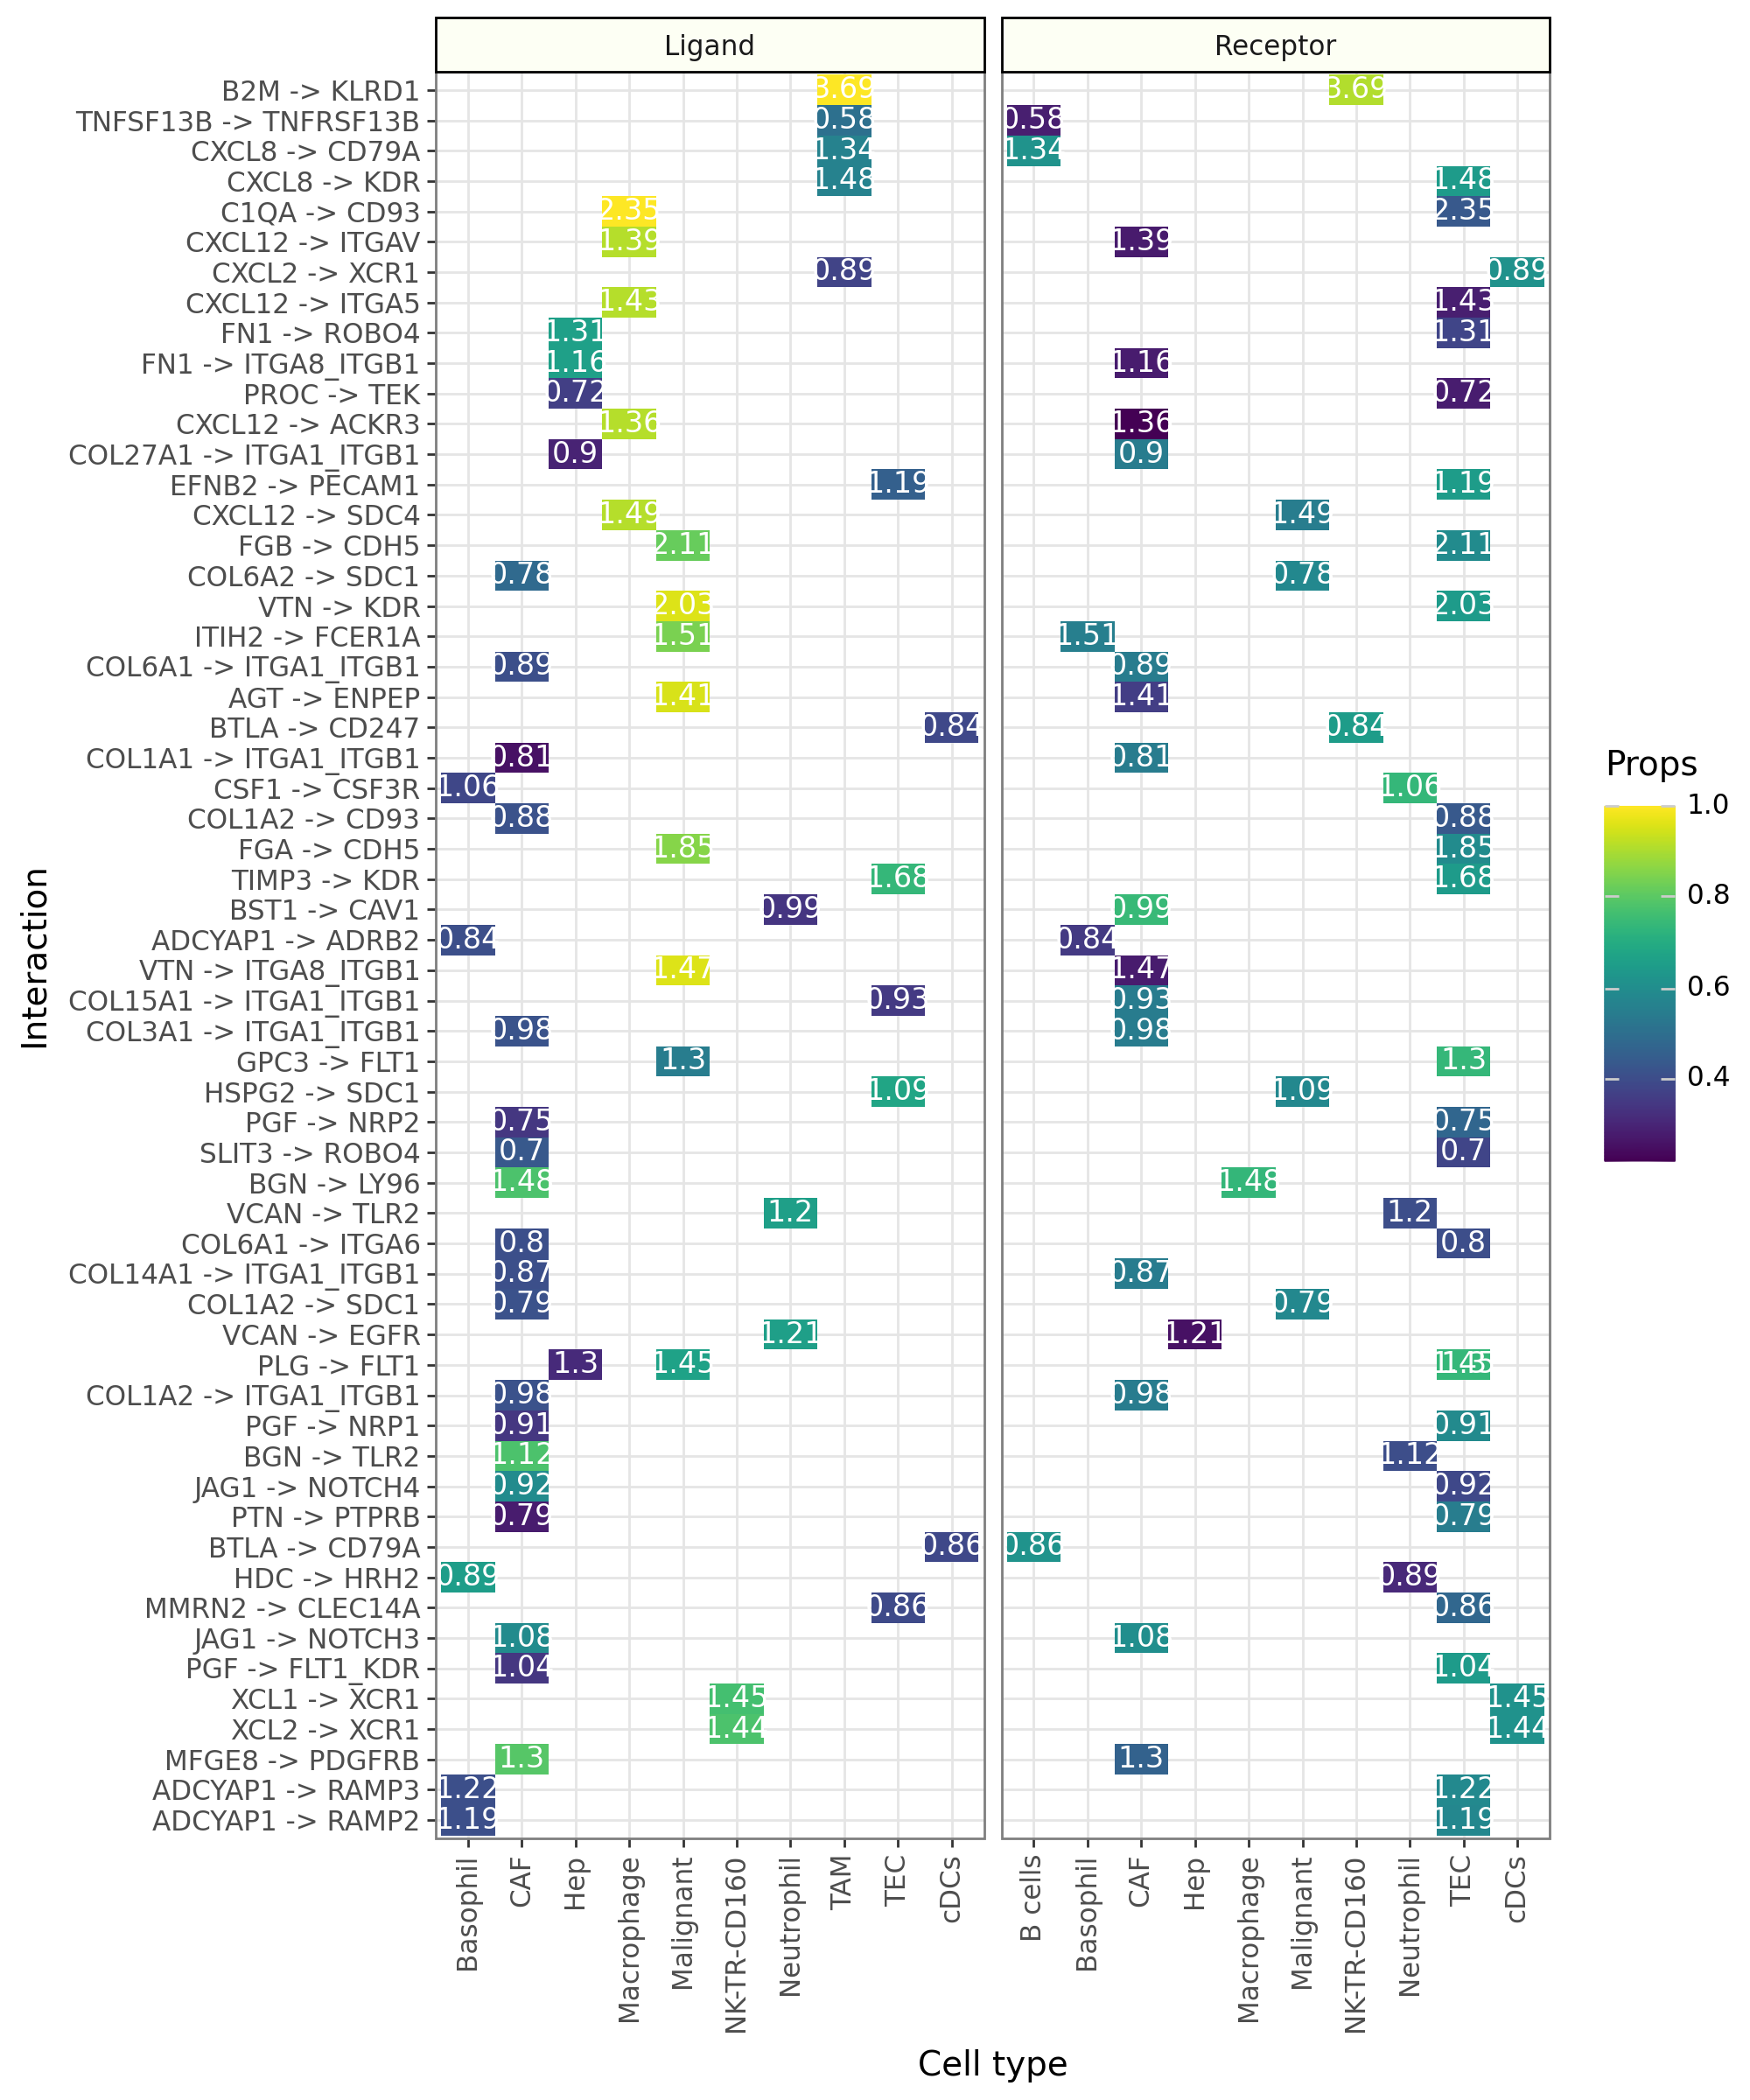

In [40]:
# 1) Base ordenada
df_all = _make_numeric(adata.uns['liana_res'].copy())
df_all = _ensure_complex_cols(df_all)
df_sorted = df_all.sort_values('w', ascending=False).reset_index(drop=True)

# 2) TOP-K* y adición por emisor
K_star = 45; M_per_source = 5
df_top = df_sorted.head(K_star).copy()

must_sources = ['Malignant cells','TECs','TAMs','Hepatocytes','Macrophages']
adds = [df_sorted[df_sorted['source'].astype(str)==s].head(M_per_source) for s in must_sources]
adds = [x for x in adds if not x.empty]

Lcol = 'ligand_complex'; Rcol = 'receptor_complex'
df_aug = (pd.concat([df_top]+adds, ignore_index=True)
          .drop_duplicates(subset=['source','target',Lcol,Rcol])
          .copy())

# 3) Labels presentes y label válido
sources, targets = _pick_labels_from_df(df_aug)
label_var = _pick_label_var(df_aug)
label_fun = (lambda x: float(np.round(x, 2))) if label_var != 'props' else None

# 4) Tileplot
my_plot = li.pl.tileplot(
    liana_res=df_aug,
    fill='props',
    label=label_var,
    **({'label_fun': label_fun} if label_fun is not None else {}),
    top_n=df_aug.shape[0],
    orderby='w', orderby_ascending=False,
    source_labels=sources, target_labels=targets,
    source_title='Ligand', target_title='Receptor',
    figure_size=(max(10, 0.55*len(targets)), max(12, 0.55*len(sources))),
)
my_plot


In [41]:
from pathlib import Path
outdir = Path("/home/mdiaz/HCC_project/MERGED_analysis/figures/"); outdir.mkdir(parents=True, exist_ok=True)
my_plot.save(outdir / f"Specific_tileplot_topK{K_star}.png", dpi=300, verbose=False)

In [28]:
import numpy as np, pandas as pd
import liana as li

# ---------- helpers ----------
def _make_numeric(df):
    num_cols = ['magnitude_rank','specificity_rank','ligand_props','receptor_props',
                'lr_means','lr_probs','lrscore','expr_prod','cellchat_pvals','cellphone_pvals','w']
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    if 'w' not in df.columns and {'magnitude_rank','specificity_rank'} <= set(df.columns):
        df['score'] = 1 - df['magnitude_rank']
        df['spec']  = 1 - df['specificity_rank']
        df['w']     = df['score'] * df['spec']
    # no es estrictamente necesario para dotplot, pero no estorba:
    df = df.replace([np.inf, -np.inf], np.nan)
    return df

def _ensure_complex_cols(df):
    if 'ligand_complex' not in df.columns and 'ligand' in df.columns:
        df = df.rename(columns={'ligand':'ligand_complex'})
    if 'receptor_complex' not in df.columns and 'receptor' in df.columns:
        df = df.rename(columns={'receptor':'receptor_complex'})
    return df

Sources: ['Malignant', 'TEC']
Targets condicionados: ['Basophil', 'CAF', 'Malignant', 'TEC']


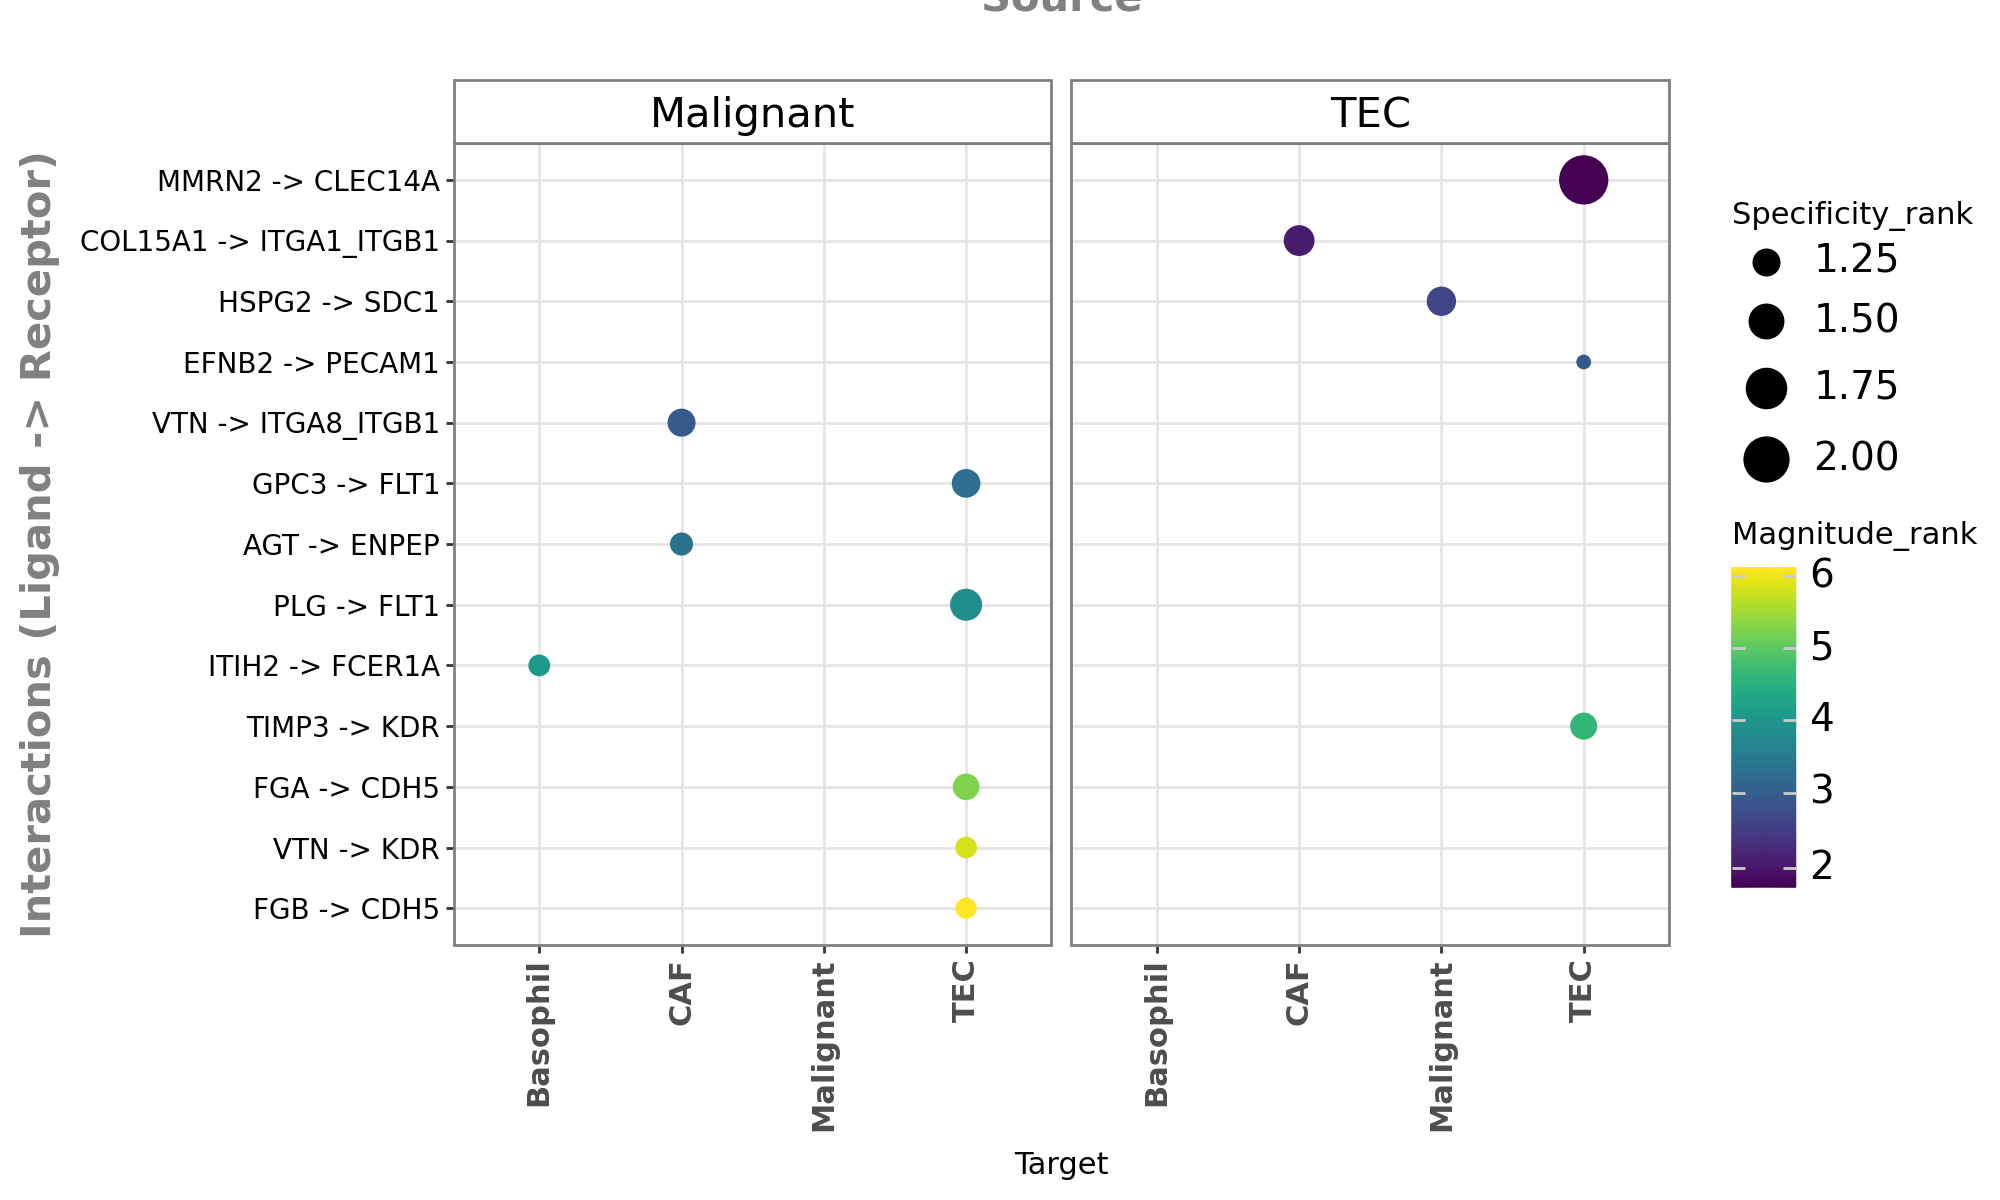

In [29]:
import numpy as np, pandas as pd
import liana as li

# --- construir df_plot (TOP-K) ---
df_all = adata.uns['liana_res'].copy()
for c in ['magnitude_rank','specificity_rank','ligand_props','receptor_props','w']:
    if c in df_all.columns: df_all[c] = pd.to_numeric(df_all[c], errors='coerce')
if 'w' not in df_all.columns:
    df_all['score'] = 1 - df_all['magnitude_rank']
    df_all['spec']  = 1 - df_all['specificity_rank']
    df_all['w']     = df_all['score'] * df_all['spec']

df_all = df_all.replace([np.inf,-np.inf], np.nan).dropna(subset=['ligand_props','receptor_props'])
df_plot = df_all.sort_values('w', ascending=False).head(45).copy()   # o 35

# --- sources solicitados y presentes ---
requested_sources = ['Malignant cells','TECs']
sources = [s for s in requested_sources if s in df_plot['source'].astype(str).unique()]

# --- targets CONDICIONADOS a esos sources (clave para evitar el ValueError) ---
targets = sorted(df_plot.loc[df_plot['source'].isin(sources), 'target'].astype(str).unique())

print("Sources:", sources)
print("Targets condicionados:", targets)

# --- dotplot ---
dot = li.pl.dotplot(
    liana_res=df_plot,
    colour='magnitude_rank',
    size='specificity_rank',
    inverse_colour=True,
    inverse_size=True,
    source_labels=sources,
    target_labels=targets,
    top_n=df_plot.shape[0],
    orderby='magnitude_rank',
    orderby_ascending=True,
    figure_size=(max(10, 0.5*len(targets)), max(6, 0.35*len(sources))),
)
dot


# Sankeyplot

In [32]:
import numpy as np, pandas as pd
import plotly.graph_objects as go

# === utilidades ya tuyas ===
def LR_cols(df):
    L = 'ligand_complex' if 'ligand_complex' in df.columns else 'ligand'
    R = 'receptor_complex' if 'receptor_complex' in df.columns else 'receptor'
    return L, R

def categorize_family(df):
    L, R = LR_cols(df)
    fam = []
    for lig, rec in zip(df[L].astype(str), df[R].astype(str)):
        if lig.startswith(('CXCL','CCL')) or rec.startswith(('CXCR','CCR','ACKR')):
            fam.append('Chemokine')
        elif lig.startswith(('IL','TNF','TGFB','IFN')) or rec.endswith(('R','RB')):
            fam.append('Cytokine')
        elif lig.startswith(('HLA','B2M')):
            fam.append('MHC')
        elif lig.startswith(('COL','LAMA','LAMB','LAMC','FN','VWF','MMRN','TNC')) or \
             lig.startswith(('ITGA','ITGB')) or rec.startswith(('ITGA','ITGB','SDC','PECAM')):
            fam.append('ECM/Adhesion')
        elif lig.startswith(('EFN','EFNB')) or rec.startswith(('EPH','EPHA','EPHB')):
            fam.append('Eph/Ephrin')
        elif lig.startswith(('FGF','EGF','VEGF','PDGF','ANGPT','ANGPTL')):
            fam.append('GrowthFactor')
        else:
            fam.append('Other')
    return pd.Series(fam, index=df.index, name='family')

# === helpers de limpieza/colores ===
def _ensure_w(df):
    g = df.copy()
    for c in ['magnitude_rank','specificity_rank','w']:
        if c in g.columns:
            g[c] = pd.to_numeric(g[c], errors='coerce')
    if 'w' not in g.columns and {'magnitude_rank','specificity_rank'} <= set(g.columns):
        g['score'] = 1 - g['magnitude_rank']
        g['spec']  = 1 - g['specificity_rank']
        g['w']     = g['score'] * g['spec']
    return g

def _hex_to_rgba(hex_color, alpha=0.6):
    hex_color = hex_color.strip('#')
    r = int(hex_color[0:2], 16); g = int(hex_color[2:4], 16); b = int(hex_color[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'

def _assign_palette(names, palette=None):
    if palette is None:
        palette = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
                   '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']
    colmap = {}
    for i, n in enumerate(names):
        colmap[n] = palette[i % len(palette)]
    return colmap

def sankey_from_df(df_in,
                   mode='family',
                   sources_wanted=None,
                   min_flow=0.0,
                   limit_mid=None,
                   valuesuffix='',
                   title='Sankey',
                   figure_size=(950, 550)):

    df = _ensure_w(df_in).copy()
    if sources_wanted:
        df = df[df['source'].astype(str).isin(sources_wanted)].copy()
    df = df[df['w'] > 0].copy()
    assert df.shape[0] > 0, "No hay filas con w>0 tras el filtrado."

    Lcol, Rcol = LR_cols(df)

    if mode == 'family':
        if 'family' not in df.columns:
            df['family'] = categorize_family(df)
        left_key, mid_key, right_key = 'source', 'family', 'target'

        sf = df.groupby([left_key, mid_key], as_index=False)['w'].sum()
        ft = df.groupby([mid_key, right_key], as_index=False)['w'].sum()
        sf = sf[sf['w'] >= min_flow]
        ft = ft[ft['w'] >= min_flow]

        if limit_mid is not None:
            fam_tot = sf.groupby(mid_key)['w'].sum().add(ft.groupby(mid_key)['w'].sum(), fill_value=0)
            keep_fams = set(fam_tot.sort_values(ascending=False).head(limit_mid).index)
            sf = sf[sf[mid_key].isin(keep_fams)]
            ft = ft[ft[mid_key].isin(keep_fams)]

        left_nodes  = sorted(sf[left_key].unique().tolist())
        mid_nodes   = sorted(set(sf[mid_key]).union(set(ft[mid_key])))
        right_nodes = sorted(ft[right_key].unique().tolist())

        if not left_nodes or not mid_nodes or not right_nodes:
            raise ValueError("No quedaron nodos tras los filtros (ajusta sources/min_flow/limit_mid).")

        left_ids  = [f"S|{s}" for s in left_nodes]
        mid_ids   = [f"M|{m}" for m in mid_nodes]
        right_ids = [f"T|{t}" for t in right_nodes]
        node_labels = left_nodes + mid_nodes + right_nodes
        node_ids    = left_ids + mid_ids + right_ids
        node_index  = {nid: i for i, nid in enumerate(node_ids)}

        fam_colors    = _assign_palette(mid_nodes)
        source_colors = _assign_palette(left_nodes)

        link_src = []; link_tgt = []; link_val = []; link_lab = []; link_col = []
        # source→family
        for _, r in sf.iterrows():
            s, m, wv = r[left_key], r[mid_key], float(r['w'])
            link_src.append(node_index[f"S|{s}"]); link_tgt.append(node_index[f"M|{m}"])
            link_val.append(wv); link_lab.append(f"{s} → {m}: w={wv:.3f}")
            link_col.append(_hex_to_rgba(fam_colors[m], 0.45))
        # family→target
        for _, r in ft.iterrows():
            m, t, wv = r[mid_key], r[right_key], float(r['w'])
            link_src.append(node_index[f"M|{m}"]); link_tgt.append(node_index[f"T|{t}"])
            link_val.append(wv); link_lab.append(f"{m} → {t}: w={wv:.3f}")
            link_col.append(_hex_to_rgba(fam_colors[m], 0.45))

        node_colors = [source_colors[s] for s in left_nodes] + \
                      [fam_colors[m] for m in mid_nodes] + \
                      ['#dddddd'] * len(right_nodes)

    elif mode == 'lr':
        df['LR'] = df[Lcol].astype(str) + "→" + df[Rcol].astype(str)
        left_key, mid_key, right_key = 'source', 'LR', 'target'

        s_lr = df.groupby([left_key, mid_key], as_index=False)['w'].sum()
        lr_t = df.groupby([mid_key, right_key], as_index=False)['w'].sum()
        s_lr = s_lr[s_lr['w'] >= min_flow]
        lr_t = lr_t[lr_t['w'] >= min_flow]

        # limitar nº de LR intermedios
        if limit_mid is not None:
            lr_tot = s_lr.groupby(mid_key)['w'].sum().add(lr_t.groupby(mid_key)['w'].sum(), fill_value=0)
            keep_lr = set(lr_tot.sort_values(ascending=False).head(limit_mid).index)
            s_lr = s_lr[s_lr[mid_key].isin(keep_lr)]
            lr_t = lr_t[lr_t[mid_key].isin(keep_lr)]  # <<< filtro directo (sin 'and/or')

        left_nodes  = sorted(s_lr[left_key].unique().tolist())
        mid_nodes   = sorted(set(s_lr[mid_key]).union(set(lr_t[mid_key])))
        right_nodes = sorted(lr_t[right_key].unique().tolist())

        if not left_nodes or not mid_nodes or not right_nodes:
            raise ValueError("No quedaron nodos tras los filtros (ajusta sources/min_flow/limit_mid).")

        left_ids  = [f"S|{s}" for s in left_nodes]
        mid_ids   = [f"M|{m}" for m in mid_nodes]
        right_ids = [f"T|{t}" for t in right_nodes]
        node_labels = left_nodes + mid_nodes + right_nodes
        node_ids    = left_ids + mid_ids + right_ids
        node_index  = {nid: i for i, nid in enumerate(node_ids)}

        src_colors = _assign_palette(left_nodes)

        link_src = []; link_tgt = []; link_val = []; link_lab = []; link_col = []
        # source→LR
        for _, r in s_lr.iterrows():
            s, lr, wv = r[left_key], r[mid_key], float(r['w'])
            link_src.append(node_index[f"S|{s}"]); link_tgt.append(node_index[f"M|{lr}"])
            link_val.append(wv); link_lab.append(f"{s} → {lr}: w={wv:.3f}")
            link_col.append(_hex_to_rgba(src_colors[s], 0.45))
        # LR→target
        for _, r in lr_t.iterrows():
            lr, t, wv = r[mid_key], r[right_key], float(r['w'])
            link_src.append(node_index[f"M|{lr}"]); link_tgt.append(node_index[f"T|{t}"])
            link_val.append(wv); link_lab.append(f"{lr} → {t}: w={wv:.3f}")
            link_col.append('rgba(120,120,120,0.35)')

        node_colors = [src_colors[s] for s in left_nodes] + \
                      ['#ccccff'] * len(mid_nodes) + \
                      ['#dddddd'] * len(right_nodes)
    else:
        raise ValueError("mode debe ser 'family' o 'lr'.")

    fig = go.Figure(data=[go.Sankey(
        valueformat=".3f",
        valuesuffix=valuesuffix,
        node=dict(pad=15, thickness=15, line=dict(color="black", width=0.5),
                  label=node_labels, color=node_colors),
        link=dict(source=link_src, target=link_tgt, value=link_val,
                  label=link_lab, color=link_col)
    )])
    fig.update_layout(title_text=title, font_size=11,
                      width=figure_size[0], height=figure_size[1])
    return fig


In [33]:
# Usa tu tabla final (por ejemplo df_top tras Jaccard + filtros)
df_use = dff.copy()  # o adata.uns['liana_res'] si quieres sobre el total

# Si df_use no tiene 'w', se calculará como (1 - magnitude_rank)*(1 - specificity_rank)
# Fija tus sources:
sources_wanted = ['Malignant cells','TECs','TAMs','Hepatocytes','Macrophages']

# 1) Sankey por FAMILIA (reduciendo flujos muy pequeños y mostrando hasta 8 familias)
fig1 = sankey_from_df(df_use,
                      mode='family',
                      sources_wanted=sources_wanted,
                      min_flow=0.0,
                      limit_mid=8,
                      title='Source → Family → Target (sum(w))')


# 2) Sankey por L–R (mostrar, por ejemplo, los 50 LR intermedios más pesados)
fig2 = sankey_from_df(df_use,
                      mode='lr',
                      sources_wanted=sources_wanted,
                      min_flow=0.0,
                      limit_mid=50,
                      title='Source → L–R → Target (sum(w))')


# (Opcional) Exporta a HTML interactivo:
# fig1.write_html('sankey_family.html'); fig2.write_html('sankey_lr.html')


In [34]:
fig1.write_html("sankey_family.html", include_plotlyjs="cdn")
fig2.write_html("sankey_lr.html", include_plotlyjs="cdn")
# Abre los .html con tu navegador


In [36]:
import sys, importlib
print("Python:", sys.executable)
print("plotly version:", __import__("plotly").__version__)
print("kaleido found?:", importlib.util.find_spec("kaleido") is not None)


Python: /home/mdiaz/miniconda3/envs/liana_kernel/bin/python
plotly version: 6.3.1
kaleido found?: True


### PLot with pathways

In [37]:
import numpy as np, pandas as pd

# --- columnas L/R según existan ---
def LR_cols(df):
    L = 'ligand_complex' if 'ligand_complex' in df.columns else 'ligand'
    R = 'receptor_complex' if 'receptor_complex' in df.columns else 'receptor'
    return L, R

# --- descomponer un complejo tipo "ITGA6_ITGB1" -> ['ITGA6','ITGB1'] ---
def explode_complex(name: str):
    if pd.isna(name): return []
    return [g for g in str(name).split('_') if g]  # ajusta si tus separadores cambian

# --- asegurar w y tipos numéricos ---
def ensure_w(df):
    g = df.copy()
    for c in ['magnitude_rank','specificity_rank','ligand_props','receptor_props','w']:
        if c in g.columns: g[c] = pd.to_numeric(g[c], errors='coerce')
    if 'w' not in g.columns and {'magnitude_rank','specificity_rank'} <= set(g.columns):
        g['score'] = 1 - g['magnitude_rank']
        g['spec']  = 1 - g['specificity_rank']
        g['w']     = g['score'] * g['spec']
    g = g.dropna(subset=['w','ligand_props','receptor_props'])
    return g

# --- pasar interacciones a genes con pesos; modo: 'ligand' | 'receptor' | 'both' ---
def gene_weights_from_lr(df, mode='both'):
    df = ensure_w(df)
    Lcol, Rcol = LR_cols(df)

    rows = []
    for _, r in df.iterrows():
        w = float(r['w'])
        # peso base penalizado por expresión mínima de la pareja
        base = w * float(min(r['ligand_props'], r['receptor_props']))
        lig_genes = explode_complex(r[Lcol])
        rec_genes = explode_complex(r[Rcol])

        if mode in ('ligand','both') and lig_genes:
            w_each = base / max(len(lig_genes), 1)
            for g in lig_genes:
                rows.append((r['source'], r['target'], 'ligand', g, w_each))
        if mode in ('receptor','both') and rec_genes:
            w_each = base / max(len(rec_genes), 1)
            for g in rec_genes:
                rows.append((r['source'], r['target'], 'receptor', g, w_each))

    gw = pd.DataFrame(rows, columns=['source','target','side','gene','w_gene'])
    # opcional: quedarte sólo con genes presentes en tu anndata
    # gw = gw[gw['gene'].isin(adata.var_names.astype(str))]
    return gw

# --- construir rankings por grupo ---
# group='source'  → ranking por emisor (agrega sobre todos los targets)
# group='pair'    → ranking por par emisor→receptor
def build_rankings(gw, group='source'):
    if group == 'source':
        grp = gw.groupby(['source','gene'])['w_gene'].sum().reset_index()
        out = {s: sub.set_index('gene')['w_gene'].sort_values(ascending=False)
               for s, sub in grp.groupby('source')}
    elif group == 'pair':
        gw['pair'] = gw['source'].astype(str) + '→' + gw['target'].astype(str)
        grp = gw.groupby(['pair','gene'])['w_gene'].sum().reset_index()
        out = {p: sub.set_index('gene')['w_gene'].sort_values(ascending=False)
               for p, sub in grp.groupby('pair')}
    else:
        raise ValueError("group debe ser 'source' o 'pair'")
    return out


In [52]:
# !pip install -U gseapy statsmodels
import gseapy as gp
import pandas as pd
import numpy as np

def run_gsea_preranked(rankings: dict,
                       gene_sets='GO_Biological_Process_2021',
                       min_size=2, max_size=5000,
                       threads=4, permutation_num=200,  # ← activar p-values
                       seed=7, verbose=False):
    # resolver librería (nombre Enrichr -> dict) o aceptar .gmt/dict
    gs = gene_sets
    if isinstance(gene_sets, str) and not gene_sets.lower().endswith('.gmt'):
        gs = gp.get_library(name=gene_sets, organism='Human')

    outs = []
    for name, rnk in rankings.items():
        r = rnk.copy()
        r.index = r.index.astype(str).str.upper()
        r = r.groupby(level=0).max().sort_values(ascending=False)

        # romper empates determinísticamente
        if r.duplicated().any():
            jitter = pd.Series((r.index.map(lambda g: (hash(g) % 10_000) / 1e12)).values, index=r.index)
            r = r.astype(float) + jitter

        rnk_df = r.reset_index()
        rnk_df.columns = ['gene','score']

        pre = gp.prerank(rnk=rnk_df, gene_sets=gs,
                         min_size=min_size, max_size=max_size,
                         permutation_num=permutation_num,  # <<<<
                         threads=threads, outdir=None, seed=seed, verbose=verbose)
        if pre is None or pre.res2d is None or pre.res2d.empty: 
            continue

        dfres = pre.res2d.copy()
        outs.append(dfres.assign(set=name))

    return pd.concat(outs, axis=0, ignore_index=True) if outs else pd.DataFrame()


In [53]:
def normalize_gsea_cols(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()

    # quitar columnas duplicadas por nombre (ignorando mayúsculas)
    seen, keep = set(), []
    for c in df.columns:
        lc = c.lower()
        if lc in seen: 
            continue
        seen.add(lc); keep.append(c)
    df = df[keep].copy()

    # map de nombres variados → estándar
    rename = {}
    for c in df.columns:
        lc = c.lower().strip()
        if lc in {'term','name','description','geneset','gene_set','pathway','go term','go_term'}:
            rename[c] = 'term'
        elif lc in {'nes','normalized enrichment score','normalized_es'}:
            rename[c] = 'nes'
        elif lc in {'es','enrichment score','enrichment_score'}:
            rename[c] = 'es'
        elif lc in {'fdr','fdr q-val','fdr q-value','q-value','qvalue','adj p','adj_p','adjusted p-value'}:
            rename[c] = 'fdr'
        elif lc in {'pval','p','p-value','pvalue','p_val','nominal p-value','pval nominal'}:
            rename[c] = 'pval'
        elif lc in {'set','source','group'}:
            rename[c] = 'set'
    df = df.rename(columns=rename)

    # tipos numéricos
    for c in ('nes','es','fdr','pval'):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')

    if 'set' not in df.columns:
        df['set'] = 'ALL'

    # si falta FDR pero hay p-val → BH por set
    if 'fdr' not in df.columns and 'pval' in df.columns:
        try:
            from statsmodels.stats.multitest import multipletests
            df['fdr'] = df.groupby('set')['pval'].transform(lambda p: multipletests(p.values, method='fdr_bh')[1])
        except Exception:
            # fallback suave si no está statsmodels
            df['fdr'] = df.groupby('set')['pval'].transform(lambda p: pd.Series(p).rank()/len(p))

    # si Tampoco hay p-val: crea pseudo-FDR (ranking por NES)
    if 'fdr' not in df.columns:
        df['fdr'] = df.groupby('set')['nes'].transform(lambda x: x.rank(ascending=False)/len(x))

    # ordenar consistente
    cols = [c for c in ['term','set','nes','es','pval','fdr'] if c in df.columns]
    other = [c for c in df.columns if c not in cols]
    return df[cols + other]


In [55]:
import pandas as pd
import numpy as np

# 1) Quita duplicados de nombres de columna (conserva la 1ª)
res_src = res_src.copy()
res_src.columns = [c.strip() for c in res_src.columns]
res_src = res_src.loc[:, ~res_src.columns.duplicated()].copy()

# 2) Renombra columnas “raras” de GO a nombres simples (opcional pero útil)
res_src = res_src.rename(columns={
    'NOM p-val':'pval',
    'FWER p-val':'fwer_p',
    'Tag %':'tag_pct',
    'Gene %':'gene_pct'
})

# 3) Asegura tipos numéricos donde corresponde
for c in ['fdr','pval','nes','es','fwer_p','tag_pct','gene_pct']:
    if c in res_src.columns:
        res_src[c] = pd.to_numeric(res_src[c], errors='coerce')

# 4) Ahora sí: filtra por FDR sin usar query (evita el resolver de pandas)
thr = 0.10
dfp = res_src[res_src['fdr'] <= thr].copy()

# Si quedara vacío, toma top por NES
if dfp.empty:
    dfp = (res_src.sort_values(['set','nes'], ascending=[True, False])
                  .groupby('set').head(15))


In [81]:
# --- elige el universo de interacciones ---
# si ya construiste tu TOP por Jaccard:
#df_use = df_top.copy()
# (alternativa más amplia)
df_use = dff.copy()

# --- define los sources que quieres mostrar ---
sources_wanted = ['Malignant cells','TECs','TAMs','Hepatocytes','Macrophages']

# --- Sankey Source→Family→Target (como Imagen 2) ---
fig1 = sankey_from_df(
    df_use,
    mode='family',                 # familia (Chemokine, ECM/Adhesion, etc.)
    sources_wanted=sources_wanted, # filtra a esos sources
    min_flow=0.0,                  # puedes subirlo p.ej. 0.02 para quitar hilos finos
    limit_mid=8,                   # máximo nº de familias a mostrar
    title='Source → Family → Target (sum(w))',
    figure_size=(1100, 600)
)
fig1.show()

# --- (opcional) Sankey Source→Ligand–Receptor→Target ---
fig2 = sankey_from_df(
    df_use,
    mode='lr',                     # ahora cada nodo medio es un par L–R
    sources_wanted=sources_wanted,
    min_flow=0.0,
    limit_mid=50,                  # nº máximo de pares L–R a mostrar
    title='Source → L–R → Target (sum(w))',
    figure_size=(1300, 700)
)
fig2.show()

# Guardado (si quieres archivo):
fig1.write_html("AllInteractions_sankey_family.html", include_plotlyjs="cdn")
fig2.write_html("AllInteractions_sankey_lr.html", include_plotlyjs="cdn")


TemporaryDirectory.cleanup() worked.
shutil.rmtree worked.


In [82]:

import os, kaleido, plotly.io as pio

# Asegura el Chromium de Kaleido (no hace daño si ya está)
_ = kaleido.get_chrome_sync()

# Carpeta de salida
outdir = "./figs"
os.makedirs(outdir, exist_ok=True)

# Opcional: fondo blanco y márgenes consistentes (útil para JPG)
common_layout = dict(paper_bgcolor="white", plot_bgcolor="white",
                     margin=dict(l=10, r=10, t=40, b=10))

fig1.update_layout(**common_layout)
fig2.update_layout(**common_layout)

# Tamaños y “resolución” efectiva (scale duplica píxeles)
W1, H1 = 1600, 900   # para fig1 (family)
W2, H2 = 1800, 1000  # para fig2 (L–R)

# JPG
fig1.write_image(os.path.join(outdir, "Top45_sankey_family.jpg"), width=W1, height=H1, scale=2)
fig2.write_image(os.path.join(outdir, "Top45_sankey_lr.jpg"),     width=W2, height=H2, scale=2)


Using last known good version of chrome
Chromium init'ed with kwargs {}
Found chromium path: /datos/home/mdiaz/miniconda3/envs/liana_kernel/lib/python3.11/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
Temp directory created: /tmp/tmpqdh5blbb.
Opening browser.
Temp directory created: /tmp/tmp9n0es3p0.
Temporary directory at: /tmp/tmp9n0es3p0
Conforming 1 to file:///tmp/tmpqdh5blbb/index.html
Waiting on all navigates
All navigates done, putting them all in queue.
Getting tab from queue (has 1)
Got 7DEB
Processing Source__Family__Target_sumw.jpeg
Sending big command for Source__Family__Target_sumw.jpeg.
Sent big command for Source__Family__Target_sumw.jpeg.
Reloading tab 7DEB before return.
Putting tab 7DEB back (queue size: 0).
Waiting for all cleanups to finish.
Exiting Kaleido
Closing browser.
Closing browser.
TemporaryDirectory.cleanup() worked.
shutil.rmtree worked.
Cancelling tasks.
Exiting Kaleido/Choreo
TemporaryDirectory.cleanup() worked.
shutil.rmtree worked.

In [59]:
# === Sankey Source → Pathway → Target (vinculando L-R a vías) ===
import re, numpy as np, pandas as pd, plotly.graph_objects as go
import gseapy as gp  # solo si pasas un nombre de librería y no un dict

# --- utilidades ya usadas ---
def LR_cols(df):
    L = 'ligand_complex' if 'ligand_complex' in df.columns else 'ligand'
    R = 'receptor_complex' if 'receptor_complex' in df.columns else 'receptor'
    return L, R

def _ensure_w(df):
    g = df.copy()
    for c in ['magnitude_rank','specificity_rank','w']:
        if c in g.columns: g[c] = pd.to_numeric(g[c], errors='coerce')
    if 'w' not in g.columns and {'magnitude_rank','specificity_rank'} <= set(g.columns):
        g['score'] = 1 - g['magnitude_rank']
        g['spec']  = 1 - g['specificity_rank']
        g['w']     = g['score'] * g['spec']
    return g

def _assign_palette(names, palette=None):
    if palette is None:
        palette = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
                   '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']
    return {n: palette[i % len(palette)] for i, n in enumerate(names)}

def _hex_to_rgba(hex_color, a=0.55):
    h = hex_color.strip('#'); r=int(h[0:2],16); g=int(h[2:4],16); b=int(h[4:6],16)
    return f'rgba({r},{g},{b},{a})'

def _split_genes(x):
    # separa complejos tipo "ITGA6_ITGB1" o "HLA-DPB1+CD4"
    s = str(x).strip()
    if not s or s.lower()=='nan': return []
    parts = re.split(r'[\s\|+:_]', s)
    return [p for p in parts if p]

def _expand_lr_genes(df):
    L, R = LR_cols(df)
    g = df.copy()
    g['_lig_genes'] = g[L].map(_split_genes)
    g['_rec_genes'] = g[R].map(_split_genes)
    g['_genes'] = g['_lig_genes'] + g['_rec_genes']
    return g

def _short(s, n=40):
    s = str(s)
    return s if len(s)<=n else (s[:n-1]+'…')

def normalize_gsea_cols(df):
    """Normaliza columnas de gseapy.prerank() por si quieres seleccionar vías desde res_src."""
    if df is None or df.empty: return pd.DataFrame()
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    df = df.loc[:, ~df.columns.duplicated()]  # quita duplicados por nombre
    df = df.rename(columns={
        'NOM p-val':'pval','FWER p-val':'fwer_p','Tag %':'tag_pct','Gene %':'gene_pct',
        'Term':'term','Description':'term','Name':'term',
        'NES':'nes','ES':'es','FDR q-val':'fdr','FDR q-value':'fdr','Q-value':'fdr',
        'Pval':'pval','P-value':'pval','p-value':'pval','pval':'pval',
        'Set':'set','group':'set'
    })
    for c in ('nes','es','fdr','pval'): 
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors='coerce')
    if 'set' not in df.columns: df['set']='ALL'
    # Si no hay fdr pero sí pval -> BH por set
    if 'fdr' not in df.columns and 'pval' in df.columns:
        try:
            from statsmodels.stats.multitest import multipletests
            df['fdr'] = df.groupby('set')['pval'].transform(lambda p: multipletests(p, method='fdr_bh')[1])
        except Exception:
            df['fdr'] = df.groupby('set')['pval'].transform(lambda p: pd.Series(p).rank()/len(p))
    return df

def sankey_pathway_from_lr(df_in,
                           gene_sets='GO_Biological_Process_2021',  # dict | nombre Enrichr | ruta .gmt (si pasas dict, no usa gseapy)
                           res_src=None,            # resultado de GSEA para elegir términos (opcional)
                           fdr_th=0.1,             # umbral para seleccionar términos desde GSEA
                           top_per_source=5,       # si nada pasa FDR, coge top NES por source
                           max_terms=20,           # límite de nº de vías en el nodo medio
                           sources_wanted=None,    # subset de sources a mostrar
                           assign='proportional',  # 'proportional' o 'binary' para repartir w
                           min_flow=0.0,           # umbral en w para ocultar flujos finos
                           title='Source → Pathway → Target (sum w)',
                           figure_size=(1200, 650)):
    df = _ensure_w(df_in)
    if sources_wanted:
        df = df[df['source'].astype(str).isin(sources_wanted)]
    df = df[df['w']>0].copy()
    if df.empty: raise ValueError("No hay interacciones con w>0 tras el filtrado.")
    df = _expand_lr_genes(df)

    # 1) Carga librería de vías
    if isinstance(gene_sets, dict):
        lib = {k:set(map(str.upper, v)) for k,v in gene_sets.items()}
    elif isinstance(gene_sets, str) and not gene_sets.lower().endswith('.gmt'):
        lib = {k:set(map(str.upper, v)) for k,v in gp.get_library(gene_sets, organism='Human').items()}
    else:
        # loader simple de GMT
        lib = {}
        with open(gene_sets) as fh:
            for line in fh:
                parts = line.strip().split('\t')
                if len(parts)>=3:
                    lib[parts[0]] = set(g.upper() for g in parts[2:])

    # 2) Selección de términos
    terms = None
    if res_src is not None and not getattr(res_src, 'empty', True):
        rs = normalize_gsea_cols(res_src)
        sel = rs[rs['fdr']<=fdr_th]
        if sel.empty:
            sel = (rs.sort_values(['set','nes'], ascending=[True,False])
                     .groupby('set').head(top_per_source))
        terms = sel['term'].astype(str).unique().tolist()
    if not terms:  # fallback por solapamiento global
        allgenes = set(g for lst in df['_genes'] for g in lst)
        ov = [(t, len(gs & set(map(str.upper, allgenes)))) for t, gs in lib.items()]
        ov = [x for x in ov if x[1]>0]
        ov.sort(key=lambda x:x[1], reverse=True)
        terms = [t for t,_ in ov[:max_terms]]
    if max_terms: terms = terms[:max_terms]

    # 3) Asignación de pesos a vías
    term_genes = {t: lib[t] for t in terms if t in lib}
    rows = []
    for _, r in df.iterrows():
        s, t, w = str(r['source']), str(r['target']), float(r['w'])
        genes = set(g.upper() for g in r['_genes'])
        hits = {term: len(genes & gs) for term, gs in term_genes.items() if len(genes & gs) > 0}
        if not hits: 
            continue
        if assign == 'proportional':
            tot = sum(hits.values())
            for term, c in hits.items():
                rows.append((s, term, t, w * (c / tot)))
        else:  # 'binary' -> reparte por igual entre vías que tocan el par
            share = w / len(hits)
            for term in hits.keys():
                rows.append((s, term, t, share))

    agg = pd.DataFrame(rows, columns=['source','term','target','w'])
    if min_flow>0:
        agg = agg[agg['w']>=min_flow]
    if agg.empty: 
        raise ValueError("No quedó flujo tras asignación/umbral. Baja min_flow o aumenta max_terms.")

    # 4) Construir el Sankey
    # nodos
    left_nodes  = sorted(agg['source'].unique().tolist())
    mid_nodes   = sorted(agg['term'].unique().tolist())
    right_nodes = sorted(agg['target'].unique().tolist())
    left_ids  = [f"S|{s}" for s in left_nodes]
    mid_ids   = [f"M|{m}" for m in mid_nodes]
    right_ids = [f"T|{t}" for t in right_nodes]
    node_labels = left_nodes + [_short(m) for m in mid_nodes] + right_nodes
    node_ids    = left_ids + mid_ids + right_ids
    node_index  = {nid:i for i,nid in enumerate(node_ids)}

    # colores
    src_colors = _assign_palette(left_nodes)
    mid_colors = _assign_palette(mid_nodes)

    # links
    sf = agg.groupby(['source','term'])['w'].sum().reset_index()
    ft = agg.groupby(['term','target'])['w'].sum().reset_index()

    link_src = []; link_tgt = []; link_val = []; link_col = []; link_lab = []
    # source → term
    for _, r in sf.iterrows():
        s, m, w = r['source'], r['term'], float(r['w'])
        link_src.append(node_index[f"S|{s}"])
        link_tgt.append(node_index[f"M|{m}"])
        link_val.append(w)
        link_col.append(_hex_to_rgba(mid_colors[m], 0.45))  # color por vía
        link_lab.append(f"{s} → {_short(m)}: w={w:.3f}")
    # term → target
    for _, r in ft.iterrows():
        m, t, w = r['term'], r['target'], float(r['w'])
        link_src.append(node_index[f"M|{m}"])
        link_tgt.append(node_index[f"T|{t}"])
        link_val.append(w)
        link_col.append(_hex_to_rgba(mid_colors[m], 0.45))
        link_lab.append(f"{_short(m)} → {t}: w={w:.3f}")

    fig = go.Figure(data=[go.Sankey(
        valueformat=".3f",
        node=dict(
            pad=15, thickness=15,
            line=dict(color="black", width=0.5),
            label=node_labels,
            color=[src_colors[s] for s in left_nodes] +
                  [mid_colors[m] for m in mid_nodes] +
                  ['#dddddd']*len(right_nodes)
        ),
        link=dict(source=link_src, target=link_tgt, value=link_val, color=link_col, label=link_lab)
    )])
    fig.update_layout(title_text=title, font_size=11, width=figure_size[0], height=figure_size[1])
    return fig, agg  # devuelvo También la tabla de flujos agregados


In [76]:
# 1) Universo (usa tu TOP-45 por Jaccard o el dff amplio)
df_use = dff.copy()   # o df_top.copy()

# 2) Fuentes de interés
sources_wanted = ['Malignant','TECs','TAMs','Hepatocytes','Macrophages']

# 3) (Opcional) Si ya corriste GSEA y tienes res_src, úsalo para elegir términos
#    res_src = normalize_gsea_cols(res_src)

# 4) Sankey por vías (GO BP), seleccionando hasta 20 términos y reparto proporcional
fig_go, flows_go = sankey_pathway_from_lr(
    df_use,
    gene_sets='GO_Biological_Process_2021',  # o un dict / .gmt
    res_src=None,            # o res_src si quieres escoger desde GSEA
    fdr_th=0.10, top_per_source=5,
    max_terms=20,
    sources_wanted=sources_wanted,
    assign='proportional',   # 'binary' si prefieres asignación 1/|vías|
    min_flow=0.0,
    title='Source → GO BP pathway → Target (sum w)',
    figure_size=(1200,650)
)
fig_go.show()

# (Opcional) Guarda a HTML
fig_go.write_html("/home/mdiaz/HCC_project/MERGED_analysis/figures/AllInteractions_sankey_go.html", include_plotlyjs="cdn")


Library is already downloaded in: /home/mdiaz/.cache/gseapy/Enrichr.GO_Biological_Process_2021.gmt, use local file
TemporaryDirectory.cleanup() worked.
shutil.rmtree worked.
0002 gene_sets have been filtered out when max_size=2000 and min_size=0


In [77]:
import kaleido, plotly, plotly.io as pio

# 1) Asegura Chromium (lo descarga si no existe)
_ = kaleido.get_chrome_sync()   # imprime "Using last known good version of chrome"

# 2) (opcional en contenedores/HPC) añade flags seguros si tu entorno lo requiere
try:
    # nuevo API (si existe)
    pio.defaults.kaleido.chromium_args = ("--no-sandbox", "--disable-dev-shm-usage")
except Exception:
    # ignora si tu plotly no expone defaults.kaleido
    pass

# 3) Exporta (no intentes fijar rutas)
fig_go.update_layout(paper_bgcolor="white", plot_bgcolor="white")
fig_go.write_image("/home/mdiaz/HCC_project/MERGED_analysis/figures/AllInteractions_sankey_go.jpg", format="jpg", width=1600, height=900, scale=2)

#print("Plotly:", plotly.__version__)


Using last known good version of chrome
Chromium init'ed with kwargs {}
Found chromium path: /datos/home/mdiaz/miniconda3/envs/liana_kernel/lib/python3.11/site-packages/choreographer/cli/browser_exe/chrome-linux64/chrome
Temp directory created: /tmp/tmp98k1jnil.
Opening browser.
Temp directory created: /tmp/tmp8zw7y3lq.
Temporary directory at: /tmp/tmp8zw7y3lq
Conforming 1 to file:///tmp/tmp98k1jnil/index.html
Waiting on all navigates
All navigates done, putting them all in queue.
Getting tab from queue (has 1)
Got 1390
Processing Source__GO_BP_pathway__Target_sum_w.jpeg
Sending big command for Source__GO_BP_pathway__Target_sum_w.jpeg.
Sent big command for Source__GO_BP_pathway__Target_sum_w.jpeg.
Reloading tab 1390 before return.
Putting tab 1390 back (queue size: 0).
Waiting for all cleanups to finish.
Exiting Kaleido
Closing browser.
Closing browser.
TemporaryDirectory.cleanup() worked.
shutil.rmtree worked.
Cancelling tasks.
Exiting Kaleido/Choreo
TemporaryDirectory.cleanup() worke

In [45]:
import gseapy as gp, pandas as pd, numpy as np

# genes presentes en tus rankings (por ejemplo, por emisor)
genes_rank = set().union(*[set(s.index) for s in rank_by_src.values()])
print("Genes únicos en ranking:", len(genes_rank))

lib = gp.get_library('Reactome_2022', organism='Human')  # dict term -> lista de genes
overlaps = {term: len(set(gs) & genes_rank) for term, gs in lib.items()}
q = np.percentile(list(overlaps.values()), [0,25,50,75,90,95,99])
print("Distribución de intersecciones (nº genes por set):", q)
print("Con >=2 genes:", sum(v>=2 for v in overlaps.values()))


Genes únicos en ranking: 25


0002 gene_sets have been filtered out when max_size=2000 and min_size=0


Distribución de intersecciones (nº genes por set): [0. 0. 0. 0. 0. 2. 4.]
Con >=2 genes: 93


# Plots

In [26]:
# === Imports ===
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations

In [27]:
# Util: columnas de LR (complejo o gen simple)
def _LR_cols(df):
    L = 'ligand_complex' if 'ligand_complex' in df.columns else 'ligand'
    R = 'receptor_complex' if 'receptor_complex' in df.columns else 'receptor'
    return L, R

# =========================================================
# 1) HEATMAP source→target (sum(w)) + z-score por fila
# =========================================================
def build_matrices(dff, ct_order=None, agg='sum'):
    """Devuelve mat (source x target) y órdenes."""
    if ct_order is None:
        ct_order = sorted(set(dff['source']).union(set(dff['target'])))
    if agg == 'sum':
        mat = (dff.groupby(['source','target'])['w']
                 .sum().unstack(fill_value=0.0)
                 .reindex(index=ct_order, columns=ct_order, fill_value=0.0))
    else:
        mat = (dff.groupby(['source','target'])['w']
                 .mean().unstack(fill_value=0.0)
                 .reindex(index=ct_order, columns=ct_order, fill_value=0.0))
    return mat, ct_order

def plot_heatmap_intensity(dff, ct_order=None, agg='sum', zscore_rows=True, vmax_pct=99):
    mat, order = build_matrices(dff, ct_order, agg=agg)
    A = mat.values.copy()
    if zscore_rows:
        mu = A.mean(axis=1, keepdims=True)
        sd = A.std(axis=1, keepdims=True)
        A = (A - mu) / (sd + 1e-9)
    vcap = np.percentile(np.abs(A), vmax_pct)
    plt.figure(figsize=(8,6))
    im = plt.imshow(A, aspect='auto', vmin=-vcap, vmax=vcap)
    plt.xticks(range(len(order)), order, rotation=90, fontsize=8)
    plt.yticks(range(len(order)), order, fontsize=8)
    ttl = f"source→target ({'z-score fila' if zscore_rows else agg})"
    plt.title(ttl)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

def plot_strength_bars(dff, ct_order=None, agg='sum'):
    mat, order = build_matrices(dff, ct_order, agg=agg)
    out_s = mat.sum(axis=1)
    in_s  = mat.sum(axis=0)

    # Out-strength
    plt.figure(figsize=(8,3))
    plt.bar(range(len(order)), out_s.values)
    plt.xticks(range(len(order)), order, rotation=90, fontsize=8)
    plt.ylabel('out-strength'); plt.title('Suma de w por emisor (source)')
    plt.tight_layout(); plt.show()

    # In-strength
    plt.figure(figsize=(8,3))
    plt.bar(range(len(order)), in_s.values)
    plt.xticks(range(len(order)), order, rotation=90, fontsize=8)
    plt.ylabel('in-strength'); plt.title('Suma de w por receptor (target)')
    plt.tight_layout(); plt.show()

# =========================================================
# 2) RED DIRIGIDA (backbone) por disparity filter (Serrano et al.)
# =========================================================
def disparity_backbone(dff, alpha=0.05):
    W = dff.groupby(['source','target'])['w'].sum().reset_index()

    # OUT (emisor)
    s_out = W.groupby('source')['w'].sum().rename('s_out')
    k_out = W.groupby('source')['target'].nunique().rename('k_out')
    W = W.merge(s_out, on='source', how='left').merge(k_out, on='source', how='left')
    # p_out = 1 - (1 - (w/s_out))**(k_out - 1)
    W['p_out'] = 1.0 - (1.0 - (W['w'] / (W['s_out']+1e-15)).clip(lower=1e-15))**(W['k_out'] - 1)

    # IN (receptor)
    s_in = W.groupby('target')['w'].sum().rename('s_in')
    k_in = W.groupby('target')['source'].nunique().rename('k_in')
    W = W.merge(s_in, on='target', how='left').merge(k_in, on='target', how='left')
    W['p_in'] = 1.0 - (1.0 - (W['w'] / (W['s_in']+1e-15)).clip(lower=1e-15))**(W['k_in'] - 1)

    back = W[(W['p_out'] < alpha) | (W['p_in'] < alpha)].copy()
    return back

def plot_directed_backbone(back, pos=None, node_size=800, label_fontsize=9):
    """Dibuja red dirigida; ancho ∝ w, alpha ∝ significancia."""
    G = nx.DiGraph()
    for _, r in back.iterrows():
        G.add_edge(r['source'], r['target'], w=float(r['w']),
                   sig=float(1.0 - min(r['p_out'], r['p_in'])))

    if pos is None:
        pos = nx.spring_layout(G, seed=42)

    # escalas
    wvals = np.array([d['w'] for *_, d in G.edges(data=True)])
    w95 = np.percentile(wvals, 95) if len(wvals) else 1.0

    plt.figure(figsize=(7,6))
    nx.draw_networkx_nodes(G, pos, node_size=node_size)
    nx.draw_networkx_labels(G, pos, font_size=label_fontsize)

    # dibuja aristas una a una para permitir alpha por-arista
    for u, v, d in G.edges(data=True):
        width = 1.0 + 4.0 * (d['w'] / (w95 + 1e-12))
        alpha = float(np.clip(0.2 + 0.8 * d['sig'], 0.2, 1.0))
        nx.draw_networkx_edges(G, pos, edgelist=[(u,v)], arrows=True,
                               width=width, alpha=alpha, arrowsize=12)
    plt.title('Backbone (disparity filter)')
    plt.axis('off'); plt.tight_layout(); plt.show()

# =========================================================
# 3) DISPERSIÓN Consenso vs Especificidad (+ etiquetas top-N)
# =========================================================
def _categorize_family(df):
    L, R = _LR_cols(df)
    fam = []
    for lig, rec in zip(df[L].astype(str), df[R].astype(str)):
        if lig.startswith(('CXCL','CCL')) or rec.startswith(('CXCR','CCR','ACKR')):
            fam.append('Chemokine')
        elif lig.startswith(('IL','TNF','TGFB','IFN')) or rec.endswith(('R','RB')):
            fam.append('Cytokine')
        elif lig.startswith(('HLA','B2M')):
            fam.append('MHC')
        elif lig.startswith(('COL','LAMA','LAMB','LAMC','FN','VWF','MMRN','TNC')) or \
             lig.startswith(('ITGA','ITGB')) or rec.startswith(('ITGA','ITGB','SDC','PECAM')):
            fam.append('ECM/Adhesion')
        elif lig.startswith(('EFN','EFNB')) or rec.startswith(('EPH','EPHA','EPHB')):
            fam.append('Eph/Ephrin')
        elif lig.startswith(('FGF','EGF','VEGF','PDGF','ANGPT','ANGPTL')):
            fam.append('GrowthFactor')
        else:
            fam.append('Other')
    return pd.Series(fam, index=df.index, name='family')

def plot_scatter_consensus_specificity(dff, top_labels=20):
    df = dff.copy()
    df['consensus'] = 1.0 - pd.to_numeric(df['magnitude_rank'])
    df['specific']  = 1.0 - pd.to_numeric(df['specificity_rank'])
    if 'method_support' not in df.columns:
        df['method_support'] = 1
    df['family'] = _categorize_family(df)

    # Tamaño ∝ soporte; normaliza
    ms = df['method_support'].astype(float)
    ms = (ms - ms.min()) / (ms.max() - ms.min() + 1e-12)
    sizes = 30 + 120 * ms

    plt.figure(figsize=(7,6))
    for fam, sub in df.groupby('family'):
        plt.scatter(sub['consensus'], sub['specific'], s=sizes.loc[sub.index], label=fam)

    # Etiquetas a las top-N por w
    L, R = _LR_cols(df)
    top = df.sort_values('w', ascending=False).head(top_labels)
    for _, r in top.iterrows():
        lab = f"{r[L]}:{r[R]} ({r['source']}→{r['target']})"
        plt.text(r['consensus'], r['specific'], lab, fontsize=7)

    plt.xlabel('Consenso (1 − magnitude_rank)')
    plt.ylabel('Especificidad (1 − specificity_rank)')
    plt.title('Consenso vs Especificidad')
    plt.legend(fontsize=8, ncol=2, frameon=False)
    plt.tight_layout(); plt.show()

# =========================================================
# 4) UpSet de soporte por método (top intersecciones)
#    Define pertenencia con ranks normalizados por método (top-q)
# =========================================================
def _norm_rank(s, high_better):
    x = pd.to_numeric(s, errors='coerce')
    r = x.rank(method='average', ascending=not high_better)
    return (r - 1) / max(len(r) - 1, 1)

def plot_upset_methods(dff, q=0.10, top_n=12):
    # Especificación de columnas por método (ajusta nombres si difieren)
    specs = [
        ('CellChat_prob',  'lr_probs',         True),
        ('CellChat_p',     'cellchat_pvals',   False),
        ('CPDB_mean',      'lr_means',         True),
        ('CPDB_p',         'cellphone_pvals',  False),
        ('NATMI_score',    'lrscore',          True),
        ('SCSR_exprprod',  'expr_prod',        True),
    ]
    specs = [(n,c,hb) for (n,c,hb) in specs if c in dff.columns]
    assert len(specs) >= 2, "Se requieren ≥2 métricas de método en dff."

    df = dff.copy()
    # Ranks por método
    for name, col, hb in specs:
        df[name+'_rank'] = _norm_rank(df[col], hb)

    # Membresías (top-q por método)
    for name, *_ in specs:
        df[name+'_in'] = (df[name+'_rank'] < q).astype(int)

    mem_cols = [n+'_in' for n, *_ in specs]
    # Intersección: codifica combinación binaria → cuenta
    combo = df[mem_cols].astype(str).agg(''.join, axis=1)
    counts = combo.value_counts().drop(labels='0'*len(mem_cols), errors='ignore')

    # Prepara datos top-N
    top = counts.head(top_n)
    labels = top.index.tolist()
    vals   = top.values

    # Gráfico de barras + matriz de puntos
    fig = plt.figure(figsize=(8,5))
    # Barras
    ax1 = fig.add_axes([0.10, 0.35, 0.85, 0.60])
    ax1.bar(range(len(vals)), vals)
    ax1.set_xticks(range(len(vals)))
    ax1.set_xticklabels(range(1, len(vals)+1), rotation=0)
    ax1.set_ylabel('Tamaño de intersección')
    ax1.set_title(f'UpSet (q={q}, top {top_n} intersecciones)')

    # Matriz
    ax2 = fig.add_axes([0.10, 0.10, 0.85, 0.20])
    for j, lab in enumerate(labels):
        for i, m in enumerate(specs):
            if lab[i] == '1':
                ax2.scatter(j, i, s=80)
            else:
                ax2.scatter(j, i, s=10, marker='x')
    ax2.set_yticks(range(len(specs)))
    ax2.set_yticklabels([n for (n, *_ ) in specs], fontsize=8)
    ax2.set_xticks(range(len(labels)))
    ax2.set_xticklabels(range(1, len(labels)+1))
    ax2.set_xlabel('Intersección (índice coincide con barras)')
    ax2.set_xlim(-0.5, len(labels)-0.5); ax2.set_ylim(-0.5, len(specs)-0.5)
    plt.show()

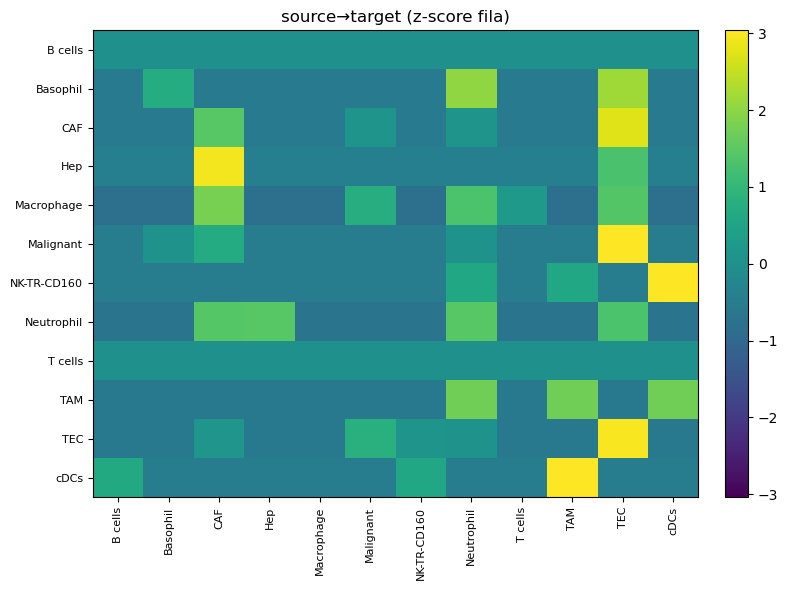

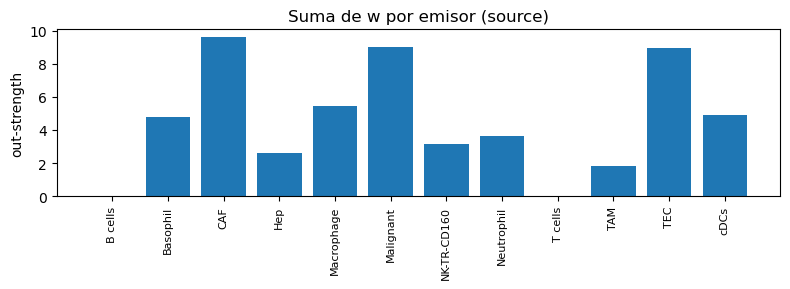

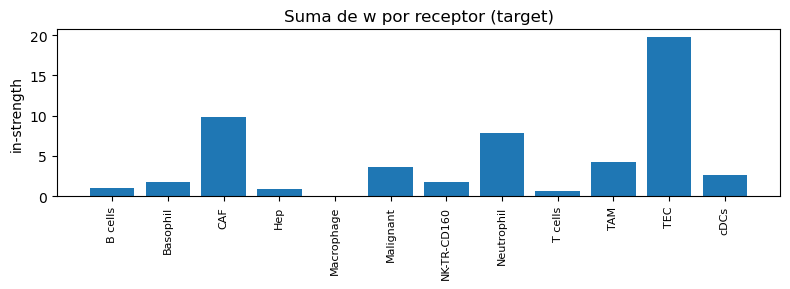

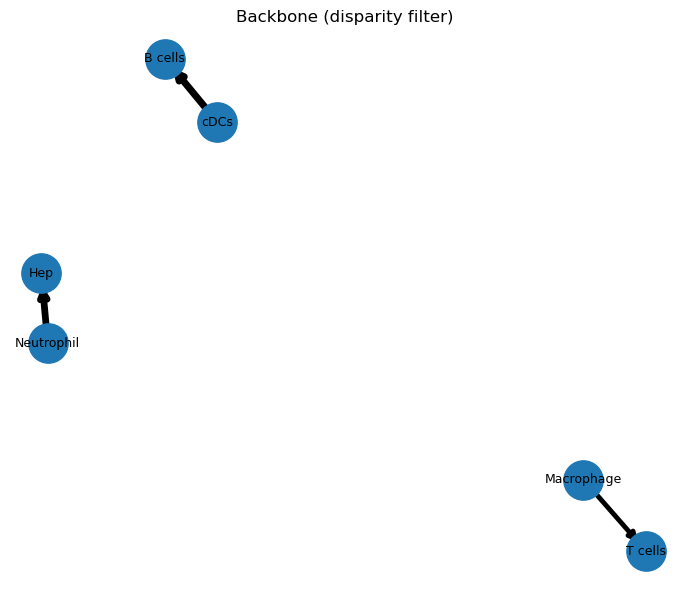

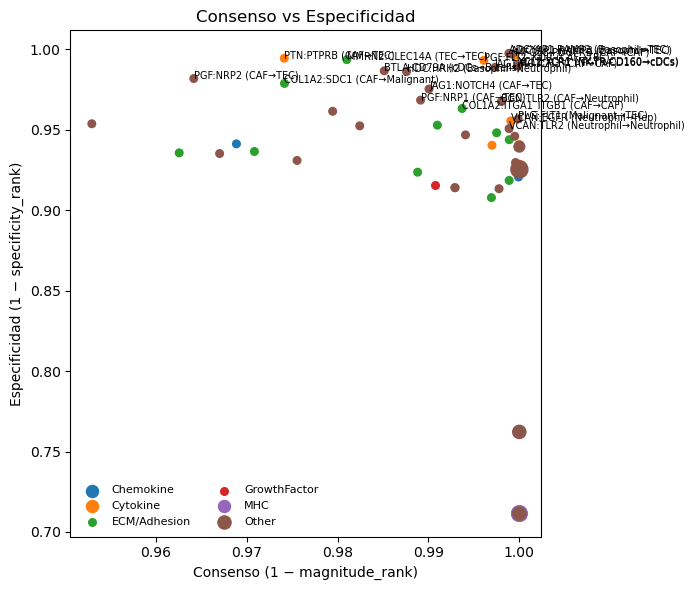

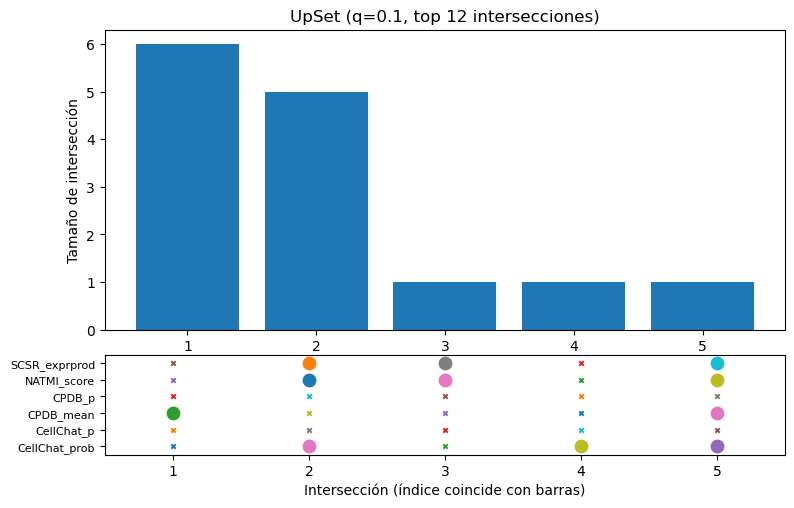

In [49]:
# 1) Heatmap + strengths
plot_heatmap_intensity(dff, ct_order=None, agg='sum', zscore_rows=True)
plot_strength_bars(dff)

# 2) Backbone disparity (alpha=0.05 por defecto)
back = disparity_backbone(dff, alpha=0.05)
plot_directed_backbone(back)

# 3) Dispersión consenso–especificidad (etiqueta top-20 por w)
plot_scatter_consensus_specificity(dff, top_labels=20)

# 4) UpSet de soporte por método (q=0.10 o 0.05)
plot_upset_methods(dff, q=0.10, top_n=12)

In [32]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from matplotlib.path import Path
from matplotlib.patches import PathPatch

In [34]:

# ------------- Utilidades comunes -------------
def LR_cols(df):
    L = 'ligand_complex' if 'ligand_complex' in df.columns else 'ligand'
    R = 'receptor_complex' if 'receptor_complex' in df.columns else 'receptor'
    return L, R

def categorize_family(df):
    L, R = LR_cols(df)
    fam = []
    for lig, rec in zip(df[L].astype(str), df[R].astype(str)):
        if lig.startswith(('CXCL','CCL')) or rec.startswith(('CXCR','CCR','ACKR')):
            fam.append('Chemokine')
        elif lig.startswith(('IL','TNF','TGFB','IFN')) or rec.endswith(('R','RB')):
            fam.append('Cytokine')
        elif lig.startswith(('HLA','B2M')):
            fam.append('MHC')
        elif lig.startswith(('COL','LAMA','LAMB','LAMC','FN','VWF','MMRN','TNC')) or \
             lig.startswith(('ITGA','ITGB')) or rec.startswith(('ITGA','ITGB','SDC','PECAM')):
            fam.append('ECM/Adhesion')
        elif lig.startswith(('EFN','EFNB')) or rec.startswith(('EPH','EPHA','EPHB')):
            fam.append('Eph/Ephrin')
        elif lig.startswith(('FGF','EGF','VEGF','PDGF','ANGPT','ANGPTL')):
            fam.append('GrowthFactor')
        else:
            fam.append('Other')
    return pd.Series(fam, index=df.index, name='family')

# =========================================================
# 1) CURVAS DE JACCARD (Estabilidad y Acuerdo entre métodos)
# =========================================================
def compute_jaccard_curves(dff, order_col='w', ascending=False,
                           step=None, Kmax=None, delta=None,
                           method_specs=None):
    """
    Devuelve:
      - stab_curve: DataFrame[K, Jaccard_stability]
      - method_curve: DataFrame[K, Jaccard_methods_mean, Jaccard_methods_sd]
      - K_star: K* por 'rodilla' (métodos si hay, si no estabilidad)
    """
    df = dff.copy()
    if order_col not in df.columns:
        df['score'] = 1 - pd.to_numeric(df['magnitude_rank'], errors='coerce')
        df['spec']  = 1 - pd.to_numeric(df['specificity_rank'], errors='coerce')
        df['w']     = df['score'] * df['spec']
        order_col, ascending = 'w', False

    # ID único de interacción
    L, R = LR_cols(df)
    df['edge_id'] = (df['source'].astype(str)+'|'+df['target'].astype(str)
                      +'|'+df[L].astype(str)+'|'+df[R].astype(str))
    df = df.sort_values(order_col, ascending=ascending).reset_index(drop=True)
    N = len(df)

    # rejilla de K
    if step is None: step = max(5, N//100)
    if Kmax is None: Kmax = min(max(50, int(N*0.15)), 1500)
    K_grid = np.arange(step, min(Kmax, N)+1, step)
    if delta is None: delta = max(step, 10)

    def top_set(K): return set(df.loc[:K-1, 'edge_id'])
    def jaccard(a, b):
        if not a and not b: return 1.0
        u = len(a|b); inter = len(a&b)
        return inter/u if u else 0.0

    # Estabilidad
    S_prev_cache = {}
    Ks_stab, J_stab = [], []
    for K in K_grid:
        S_K = top_set(K)
        Kp  = K - delta
        if Kp in S_prev_cache:
            S_prev = S_prev_cache[Kp]
        else:
            S_prev = top_set(max(step, Kp)) if Kp>0 else set()
            S_prev_cache[Kp] = S_prev
        Ks_stab.append(K); J_stab.append(jaccard(S_K, S_prev))
    stab_curve = pd.DataFrame({'K': Ks_stab, 'Jaccard_stability': J_stab})

    # Acuerdo entre métodos (si hay columnas de método)
    if method_specs is None:
        method_specs = [
            ('CellChat_prob',  'lr_probs',         True),
            ('CellChat_p',     'cellchat_pvals',   False),
            ('CPDB_mean',      'lr_means',         True),
            ('CPDB_p',         'cellphone_pvals',  False),
            ('NATMI_score',    'lrscore',          True),
            ('SCSR_exprprod',  'expr_prod',        True),
        ]
    avail = [(n,c,h) for (n,c,h) in method_specs if c in df.columns]
    def norm_rank(s, high_better):
        x = pd.to_numeric(s, errors='coerce')
        r = x.rank(method='average', ascending=not high_better)
        return (r - 1) / max(len(r)-1, 1)

    method_curve = pd.DataFrame(columns=['K','Jaccard_methods_mean','Jaccard_methods_sd'])
    rank_cols = []
    if len(avail) >= 2:
        for name, col, hb in avail:
            df[name+'_rank'] = norm_rank(df[col], hb)
            rank_cols.append(name+'_rank')
        Ks_m, Jm, Js = [], [], []
        for K in K_grid:
            sets = []
            for rcol in rank_cols:
                idx = np.argsort(df[rcol].values)[:K]  # menores = mejores
                sets.append(set(df.iloc[idx]['edge_id']))
            jvals = [jaccard(a,b) for (a,b) in combinations(sets, 2)]
            Ks_m.append(K); Jm.append(np.mean(jvals) if jvals else np.nan); Js.append(np.std(jvals) if jvals else np.nan)
        method_curve = pd.DataFrame({'K': Ks_m, 'Jaccard_methods_mean': Jm, 'Jaccard_methods_sd': Js})

    # Rodilla geométrica
    def knee_point(x, y):
        x = np.asarray(x,float); y = np.asarray(y,float)
        x_ = (x - x.min())/(x.max()-x.min()+1e-12)
        y_ = (y - y.min())/(y.max()-y.min()+1e-12)
        p1 = np.array([x_[0], y_[0]]); p2 = np.array([x_[-1], y_[-1]])
        v  = p2 - p1; v /= (np.linalg.norm(v)+1e-12)
        d  = np.abs((y_ - p1[1])*v[0] - (x_ - p1[0])*v[1])
        return int(x[np.nanargmax(d)])

    K_star = None
    if not method_curve.empty and method_curve['Jaccard_methods_mean'].notna().sum()>=3:
        v = method_curve.dropna()
        K_star = knee_point(v['K'].values, v['Jaccard_methods_mean'].values)
    else:
        v = stab_curve.dropna()
        K_star = knee_point(v['K'].values, v['Jaccard_stability'].values)
    return stab_curve, method_curve, K_star

def plot_jaccard_curves(stab_curve, method_curve, K_star, K_sens=None):
    # Estabilidad
    plt.figure(figsize=(6,4))
    plt.plot(stab_curve['K'], stab_curve['Jaccard_stability'])
    if K_star is not None:
        ys = np.interp(K_star, stab_curve['K'], stab_curve['Jaccard_stability'])
        plt.axvline(K_star, linestyle='--'); plt.scatter([K_star],[ys])
        plt.text(K_star, ys, f"K*={K_star}", fontsize=9)
    if K_sens is not None:
        ys = np.interp(K_sens, stab_curve['K'], stab_curve['Jaccard_stability'])
        plt.axvline(K_sens, linestyle=':'); plt.scatter([K_sens],[ys], marker='x')
        plt.text(K_sens, ys, f"K={K_sens}", fontsize=9)
    plt.xlabel('Top K'); plt.ylabel('Índice de Jaccard')
    plt.title('Estabilidad S(K) vs S(K−ΔK)')
    plt.tight_layout(); plt.show()

    # Acuerdo entre métodos
    if not method_curve.empty:
        plt.figure(figsize=(6,4))
        plt.plot(method_curve['K'], method_curve['Jaccard_methods_mean'])
        if K_star is not None:
            ym = np.interp(K_star, method_curve['K'], method_curve['Jaccard_methods_mean'])
            plt.axvline(K_star, linestyle='--'); plt.scatter([K_star],[ym])
            plt.text(K_star, ym, f"K*={K_star}", fontsize=9)
        if K_sens is not None:
            ym = np.interp(K_sens, method_curve['K'], method_curve['Jaccard_methods_mean'])
            plt.axvline(K_sens, linestyle=':'); plt.scatter([K_sens],[ym], marker='x')
            plt.text(K_sens, ym, f"K={K_sens}", fontsize=9)
        plt.xlabel('Top K'); plt.ylabel('Jaccard promedio (métodos)')
        plt.title('Acuerdo entre métodos vs K')
        plt.tight_layout(); plt.show()

# =========================================================
# 2) SANKEY / ALLUVIAL (Source → Familia → Target)
# =========================================================
def alluvial_3part(dff, min_flow=0.0, gap=0.02, width=0.12, label_size=9):
    """
    Dibuja un alluvial de 3 columnas:
        izquierda = 'source', medio = 'family', derecha = 'target'
    Los flujos son sum(w) por (source,family) y (family,target).
    """
    df = dff.copy()
    if 'family' not in df.columns:
        df['family'] = categorize_family(df)

    # Agregados
    sf = df.groupby(['source','family'])['w'].sum().reset_index()
    ft = df.groupby(['family','target'])['w'].sum().reset_index()
    sf = sf[sf['w']>=min_flow]
    ft = ft[ft['w']>=min_flow]

    # Totales por banda (para Tamaños)
    S = sf.groupby('source')['w'].sum().sort_values(ascending=False)
    F = pd.concat([sf.groupby('family')['w'].sum(), ft.groupby('family')['w'].sum()], axis=1).fillna(0).sum(axis=1)
    F = F.sort_values(ascending=False)
    T = ft.groupby('target')['w'].sum().sort_values(ascending=False)

    def layout_positions(sizes):
        tot = sizes.sum()
        y0 = 0.0
        spans = {}
        for name, val in sizes.items():
            h = val/tot if tot>0 else 0
            spans[name] = (y0, y0+h)
            y0 += h + gap
        scale = y0 - gap  # altura total ocupada
        return spans, max(scale, 1e-6)

    left_pos, H1 = layout_positions(S)
    mid_pos,  H2 = layout_positions(F)
    right_pos,H3 = layout_positions(T)
    Hmax = max(H1,H2,H3)

    fig, ax = plt.subplots(figsize=(10,6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, Hmax)
    ax.axis('off')

    # helper para ribbon curvo entre (x0, y0a..y0b) y (x1, y1a..y1b)
    def ribbon(x0, x1, y0a, y0b, y1a, y1b, color=None, alpha=0.6):
        verts = [
            (x0, y0a), (x0+0.05, y0a), (x1-0.05, y1a), (x1, y1a),
            (x1, y1b), (x1-0.05, y1b), (x0+0.05, y0b), (x0, y0b),
            (x0, y0a)
        ]
        codes = [
            Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
            Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4,
            Path.CLOSEPOLY
        ]
        patch = PathPatch(Path(verts, codes), lw=0.5, alpha=alpha, facecolor=color, edgecolor='k')
        ax.add_patch(patch)

    # paleta por familia (usar ciclo por defecto de matplotlib)
    fam_colors = {}
    for i, fam in enumerate(F.index):
        fam_colors[fam] = None  # deja que matplotlib elija por ciclo si se usa en parches sucesivos

    # Dibuja ribbons: source→family
    xL, xM, xR = 0.1, 0.5, 0.9
    # Acumular offsets verticales por (lado, nodo)
    off_S = {k: left_pos[k][0] for k in S.index}
    off_F1= {k: mid_pos[k][0]  for k in F.index}
    for _, r in sf.iterrows():
        s, f, wv = r['source'], r['family'], r['w']
        if wv <= 0: continue
        h = wv / S.sum() if S.sum()>0 else 0
        y0a = off_S[s]; y0b = y0a + h
        # en familia, asignar proporción relativa al total F
        hf = wv / F.sum() if F.sum()>0 else 0
        y1a = off_F1[f]; y1b = y1a + hf
        off_S[s]  = y0b
        off_F1[f] = y1b
        col = fam_colors[f]
        ribbon(xL, xM, y0a, y0b, y1a, y1b, color=col, alpha=0.65)

    # family→target
    off_F2= {k: mid_pos[k][0]  for k in F.index}
    off_T = {k: right_pos[k][0] for k in T.index}
    for _, r in ft.iterrows():
        f, t, wv = r['family'], r['target'], r['w']
        if wv <= 0: continue
        hf = wv / F.sum() if F.sum()>0 else 0
        y0a = off_F2[f]; y0b = y0a + hf
        ht = wv / T.sum() if T.sum()>0 else 0
        y1a = off_T[t]; y1b = y1a + ht
        off_F2[f] = y0b
        off_T[t]  = y1b
        col = fam_colors[f]
        ribbon(xM, xR, y0a, y0b, y1a, y1b, color=col, alpha=0.65)

    # barras/nodos
    def draw_nodes(positions, x, title):
        for name, (y0,y1) in positions.items():
            ax.add_patch(plt.Rectangle((x - width/2, y0), width, y1 - y0, ec='k', fc='w', lw=0.8))
            ax.text(x - width/2 - 0.01, (y0+y1)/2, name, ha='right', va='center', fontsize=label_size)
        ax.text(x, Hmax + 0.02, title, ha='center', va='bottom', fontsize=10)

    draw_nodes(left_pos,  xL, 'Source')
    draw_nodes(mid_pos,   xM, 'Family')
    draw_nodes(right_pos, xR, 'Target')
    plt.title('Alluvial Source → Family → Target (sum(w))')
    plt.tight_layout(); plt.show()

# =========================================================
# 3) DISTRIBUCIONES DE w (violines / box) por emisor o familia
# =========================================================
def plot_distributions_w(dff, by='source', violin=True, rotate=90):
    df = dff.copy()
    if by == 'family':
        df['family'] = categorize_family(df)
        groups = df.groupby('family')['w'].apply(list)
    else:
        groups = df.groupby('source')['w'].apply(list)
    labels = list(groups.index); data = list(groups.values)

    plt.figure(figsize=(max(8, len(labels)*0.6), 4))
    if violin:
        parts = plt.violinplot(data, showextrema=True, showmedians=True)
        # matplotlib setea colores por defecto; no forzamos estilos
        plt.title(f'Violin de w por {by}')
    else:
        plt.boxplot(data, showfliers=False)
        plt.title(f'Boxplot de w por {by}')

    plt.xticks(range(1, len(labels)+1), labels, rotation=rotate, ha='right', fontsize=8)
    plt.ylabel('w'); plt.tight_layout(); plt.show()

# =========================================================
# 4) MATRIZ DE CONTEOS (# LR por par source→target)
# =========================================================
def plot_counts_matrix(dff, ct_order=None, rotate=90):
    df = dff.copy()
    if ct_order is None:
        ct_order = sorted(set(df['source']).union(set(df['target'])))
    mat = (df.groupby(['source','target']).size()
             .unstack(fill_value=0)
             .reindex(index=ct_order, columns=ct_order, fill_value=0))
    A = mat.values
    vmax = np.percentile(A, 99)
    plt.figure(figsize=(8,6))
    im = plt.imshow(A, aspect='auto', vmin=0, vmax=max(vmax, 1))
    plt.xticks(range(len(ct_order)), ct_order, rotation=rotate, fontsize=8)
    plt.yticks(range(len(ct_order)), ct_order, fontsize=8)
    plt.title('# de interacciones (conteo de LR)')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

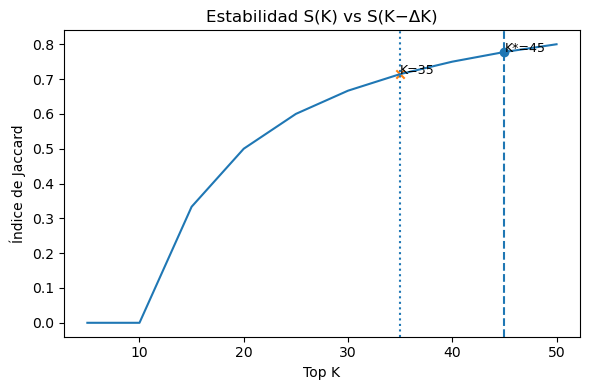

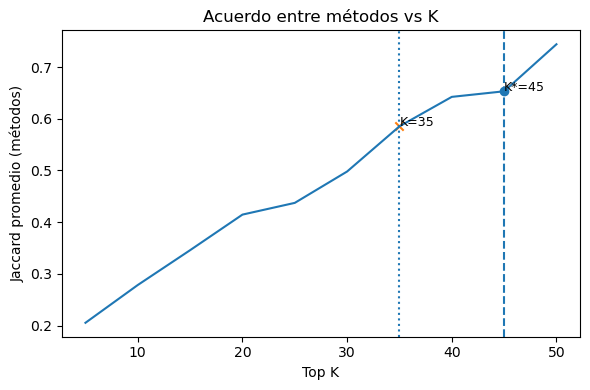

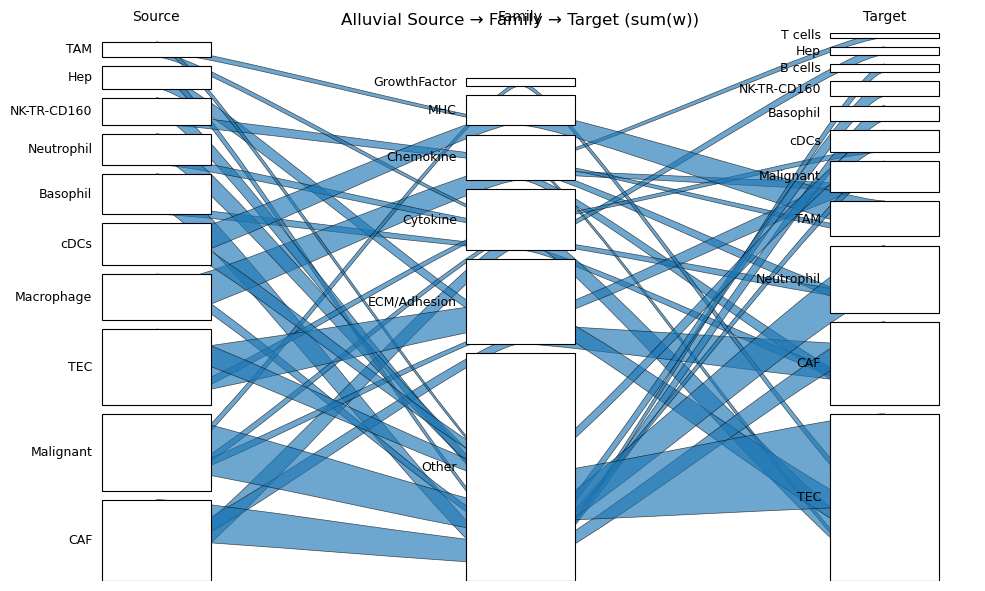

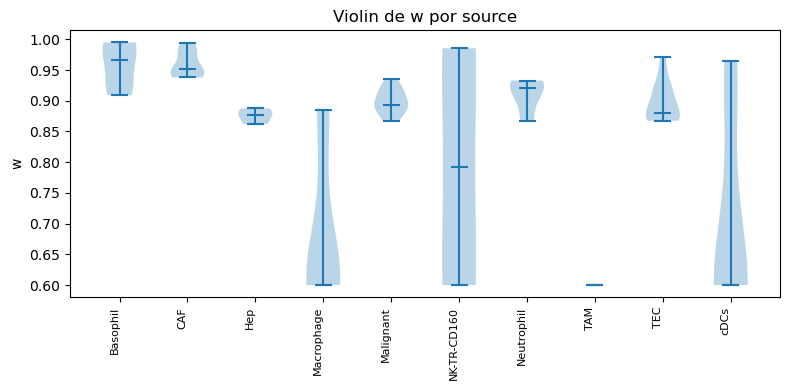

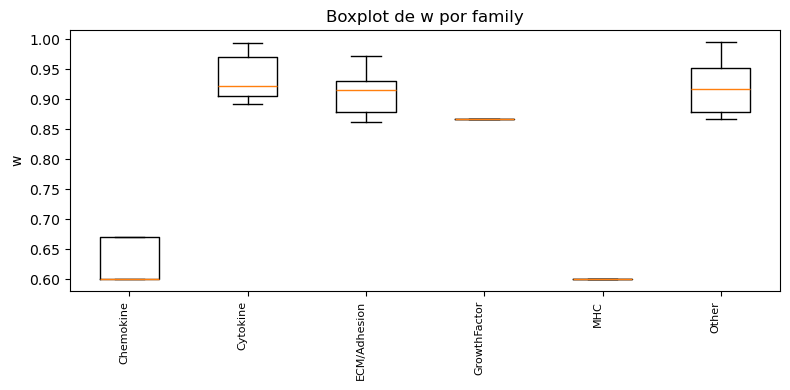

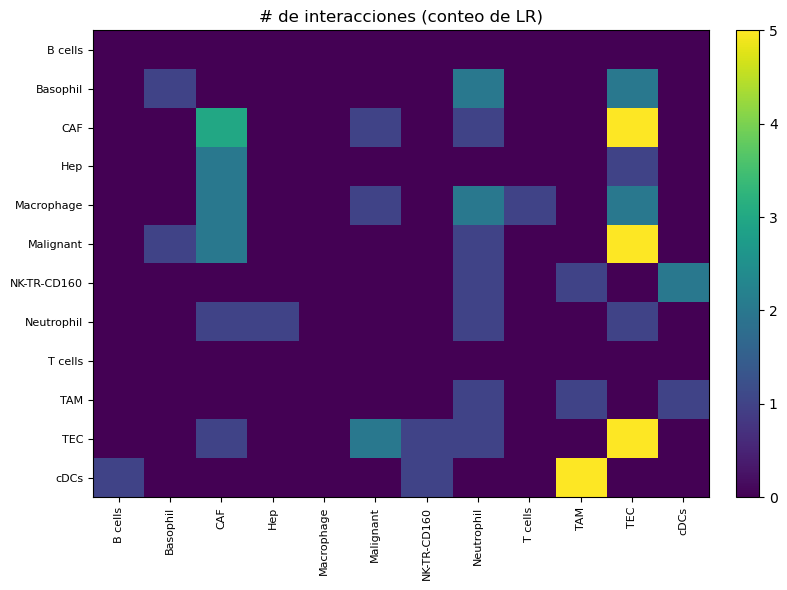

In [48]:
# 1) Curvas Jaccard
stab, meth, K_star = compute_jaccard_curves(dff, order_col='w', ascending=False)
plot_jaccard_curves(stab, meth, K_star, K_sens=35)

# 2) Alluvial 3-partes (puedes subir min_flow para reducir clutter)
alluvial_3part(dff, min_flow=0.0)

# 3) Distribuciones de w
plot_distributions_w(dff, by='source', violin=True)
plot_distributions_w(dff, by='family', violin=False)

# 4) Matriz de conteos
plot_counts_matrix(dff)

# Plots por L-R

In [39]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def _LR_cols(df):
    L = 'ligand_complex' if 'ligand_complex' in df.columns else 'ligand'
    R = 'receptor_complex' if 'receptor_complex' in df.columns else 'receptor'
    return L, R

def plot_lr_lollipop(dff, top=None):
    df = dff.copy()
    L,R = _LR_cols(df)
    df['label'] = df[L].astype(str)+'→'+df[R].astype(str)+'  ('+df['source'].astype(str)+'→'+df['target'].astype(str)+')'
    df = df.sort_values('w', ascending=False).reset_index(drop=True)
    if top: df = df.head(top)
    y = np.arange(len(df))[::-1]
    plt.figure(figsize=(8, max(4, 0.35*len(df))))
    plt.hlines(y, 0, df['w'], linewidth=2)
    plt.plot(df['w'], y, 'o')
    plt.yticks(y, df['label'], fontsize=8)
    plt.xlabel('w  (consenso ponderado)')
    plt.title('Ranking de interacciones L–R seleccionadas')
    plt.tight_layout(); plt.show()

# Ejemplo:
# plot_lr_lollipop(dff, top=45)


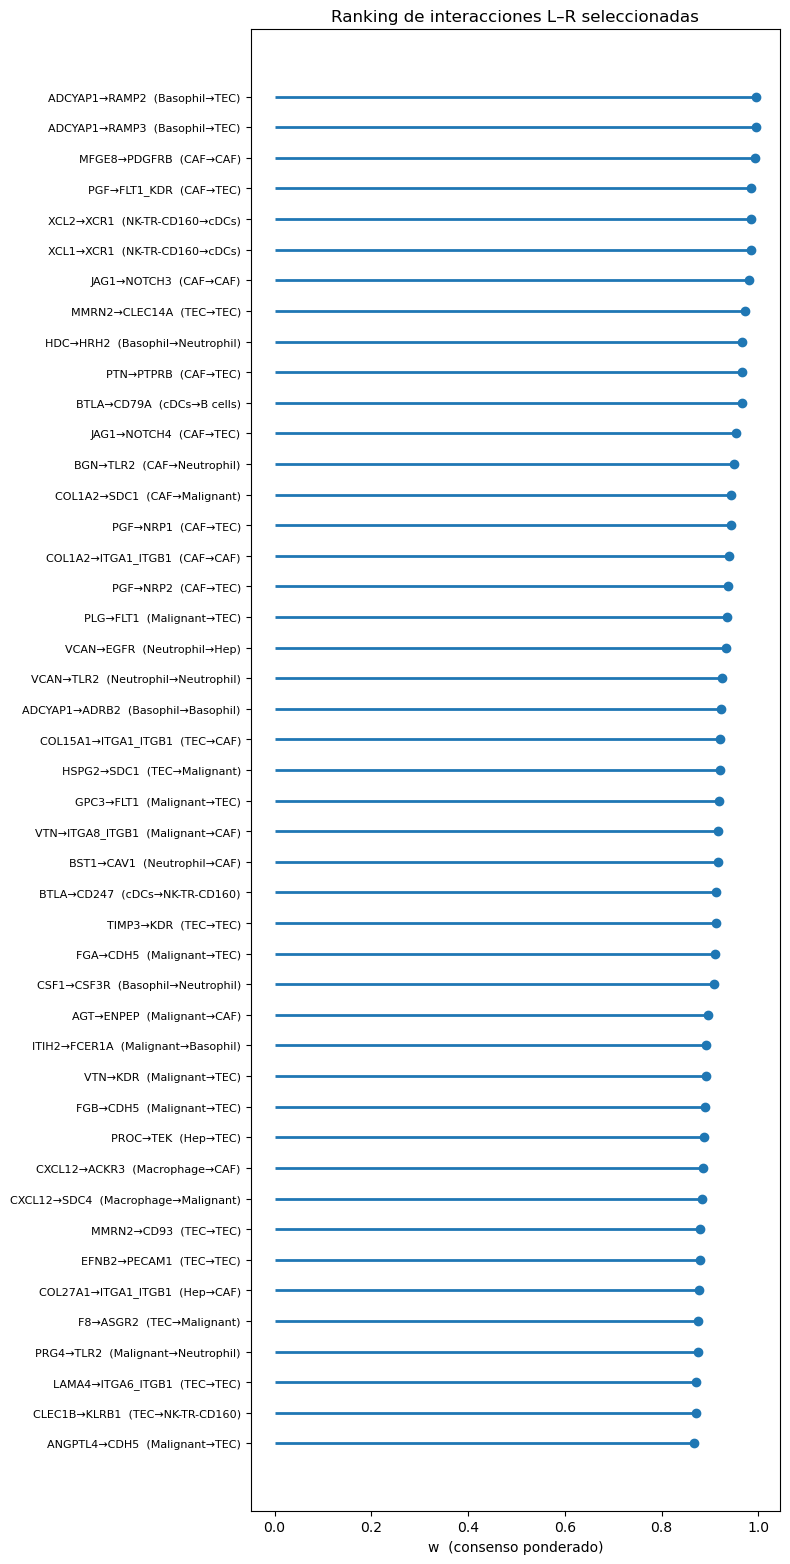

In [40]:
plot_lr_lollipop(dff, top=45)

In [41]:
def plot_lr_by_pair_heatmap(dff):
    L,R = _LR_cols(dff)
    sub = dff.copy()
    sub['pair'] = sub['source'].astype(str)+'→'+sub['target'].astype(str)
    # solo columnas (pares) presentes en el TOP
    mat = sub.pivot_table(index=[L,R], columns='pair', values='w', aggfunc='sum', fill_value=0.0)
    # ordenar filas por norma de w
    order_rows = np.argsort(-np.linalg.norm(mat.values, axis=1))
    mat = mat.iloc[order_rows]

    A = mat.values
    vmax = np.percentile(A[A>0], 95) if (A>0).any() else 1.0
    plt.figure(figsize=(min(16, 1.2*mat.shape[1]), max(4, 0.35*mat.shape[0])))
    im = plt.imshow(A, aspect='auto', vmin=0, vmax=vmax)
    yt = [f'{i[0]}→{i[1]}' for i in mat.index]
    plt.yticks(range(mat.shape[0]), yt, fontsize=7)
    plt.xticks(range(mat.shape[1]), mat.columns, rotation=90, fontsize=8)
    plt.title('w por L–R y par celular')
    plt.colorbar(im, fraction=0.02, pad=0.01)
    plt.tight_layout(); plt.show()

# Ejemplo:
# plot_lr_by_pair_heatmap(dff)


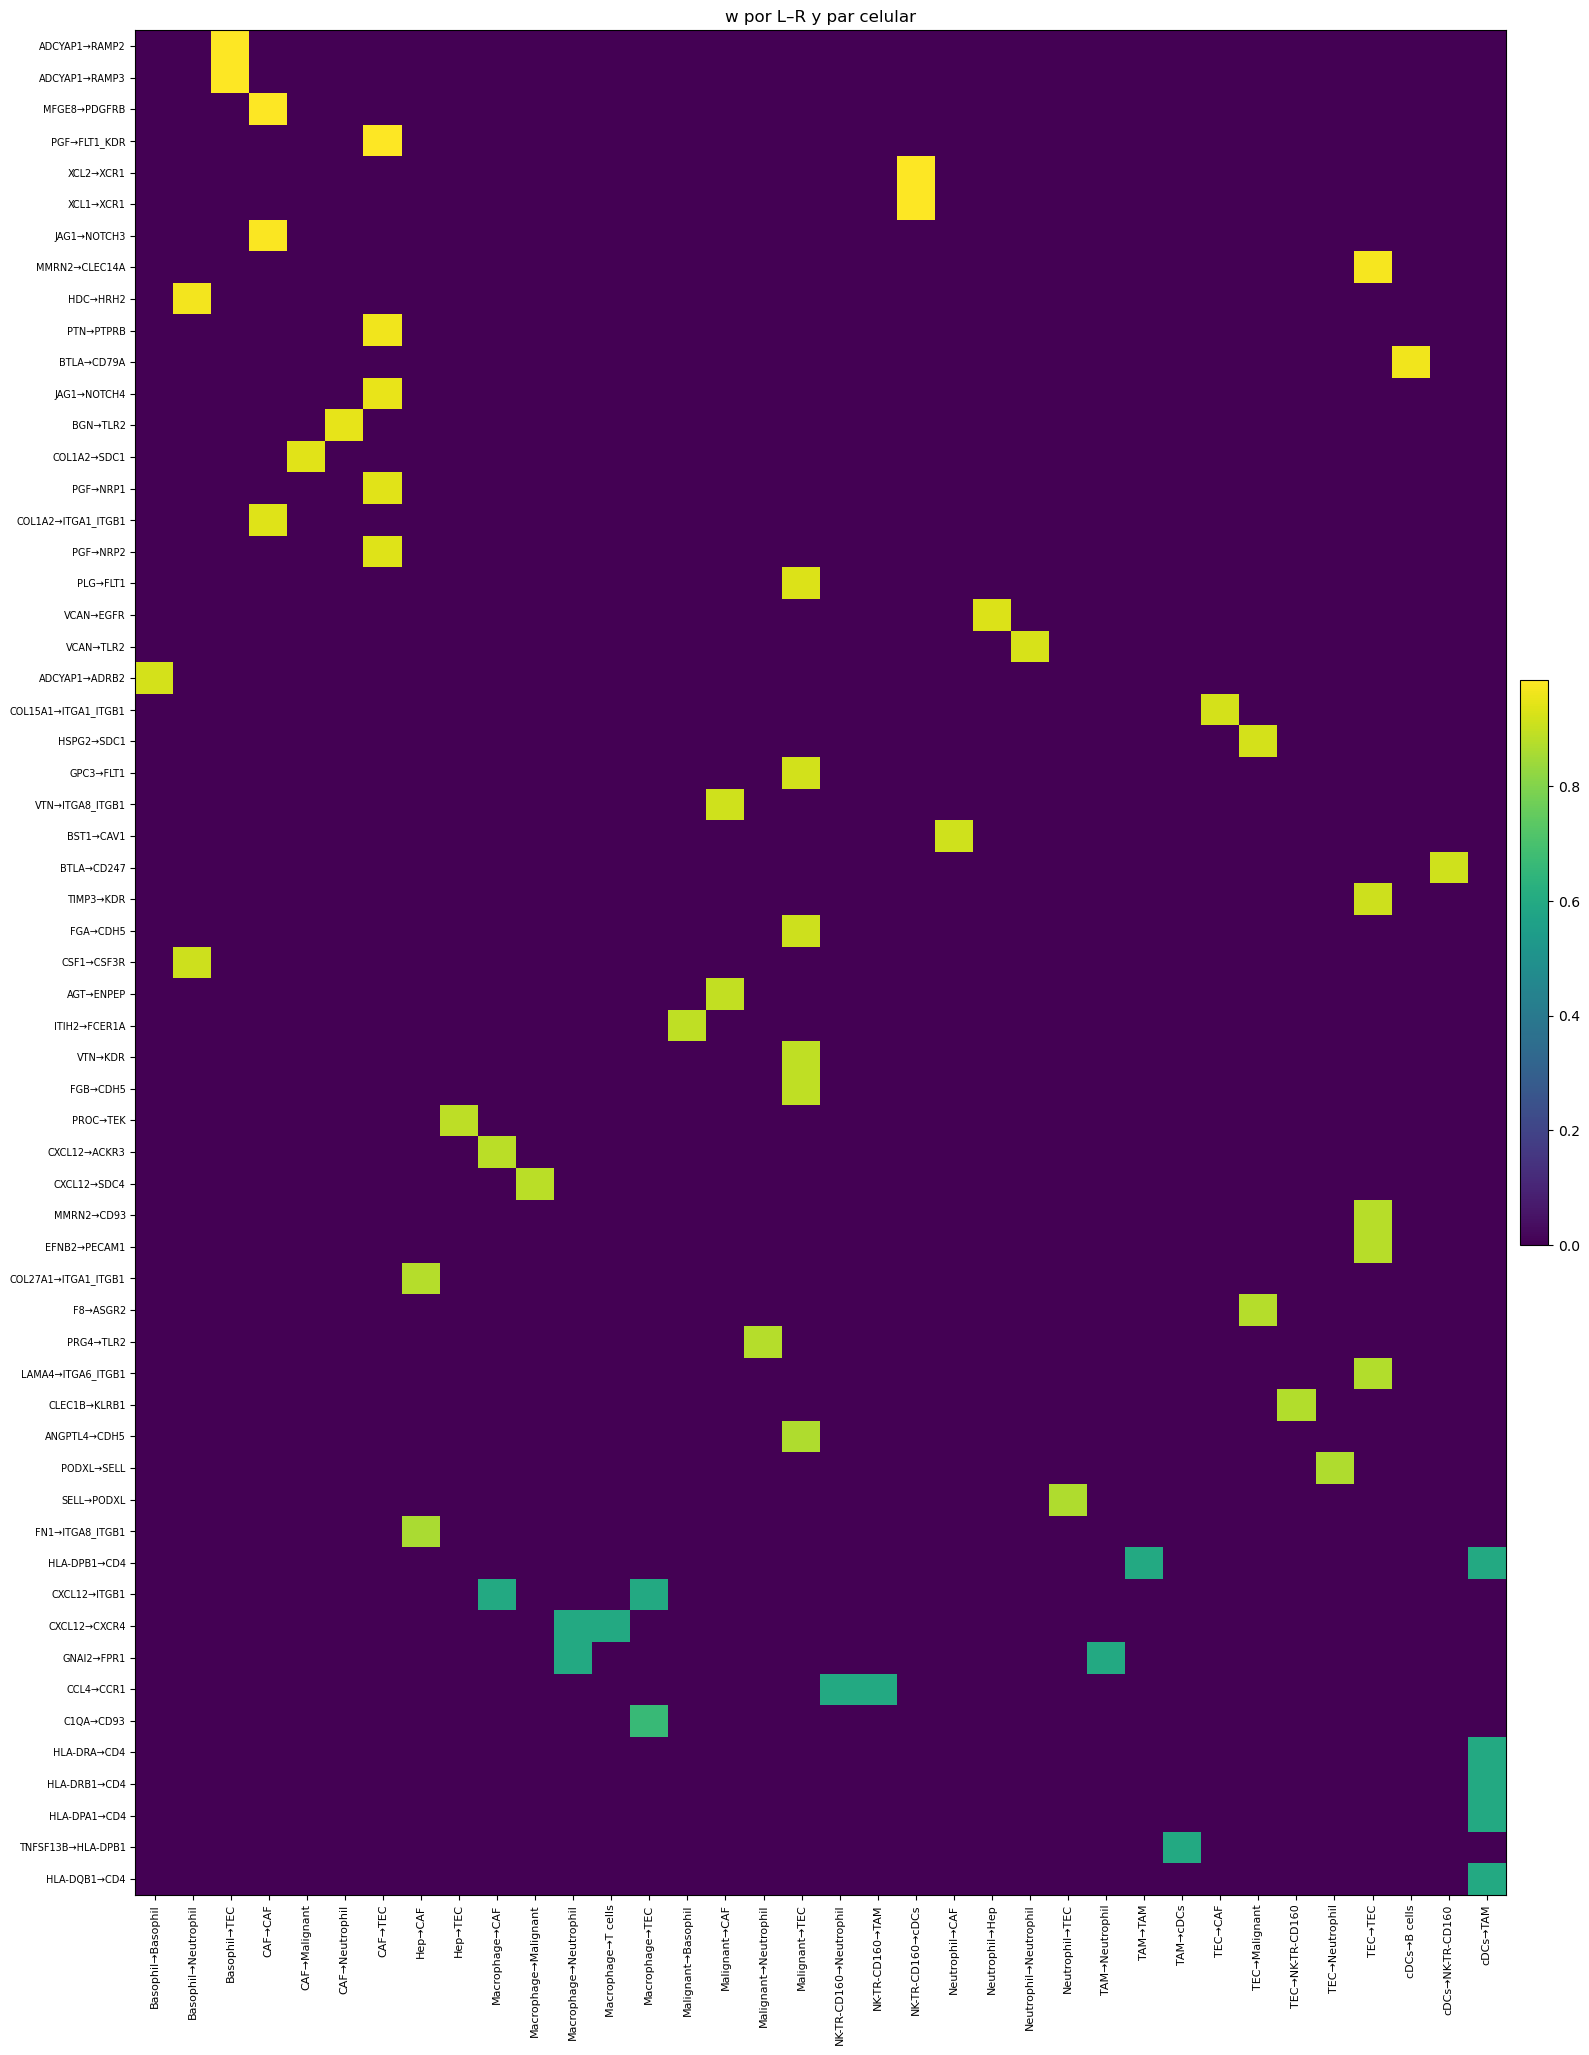

In [42]:
plot_lr_by_pair_heatmap(dff)

In [45]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def plot_lr_method_barcode(dff, q=0.10):
    df = dff.copy()
    L,R = _LR_cols(df)
    df['LR_label'] = df[L].astype(str)+'→'+df[R].astype(str)+'  ('+df['source'].astype(str)+'→'+df['target'].astype(str)+')'
    df = df.sort_values('w', ascending=False).reset_index(drop=True)

    specs = [
        ('CellChat_prob',  'lr_probs',         True),
        ('CellChat_p',     'cellchat_pvals',   False),
        ('CPDB_mean',      'lr_means',         True),
        ('CPDB_p',         'cellphone_pvals',  False),
        ('NATMI_score',    'lrscore',          True),
        ('SCSR_exprprod',  'expr_prod',        True),
    ]
    specs = [(n,c,hb) for (n,c,hb) in specs if c in df.columns]
    assert len(specs)>=2, "Se requieren ≥2 métricas de método en dff."

    def norm_rank(s, high_better):
        x = pd.to_numeric(s, errors='coerce')
        r = x.rank(method='average', ascending=not high_better)
        return (r - 1) / max(len(r)-1, 1)

    for name,col,hb in specs:
        df[name+'_rank'] = norm_rank(df[col], hb)
        df[name+'_in']   = (df[name+'_rank'] < q).astype(int)

    mem_cols = [n+'_in' for (n,_,_) in specs]
    M = df[mem_cols].values
    nL, nM = M.shape

    plt.figure(figsize=(6, max(4, 0.35*nL)))
    plt.imshow(M, aspect='auto', vmin=0, vmax=1)
    plt.xticks(range(nM), [n for (n,_,_) in specs], rotation=90, fontsize=8)
    plt.yticks(range(nL), df['LR_label'], fontsize=7)
    plt.title(f'Soporte por método (1=Top {int(q*100)}%)')
    plt.colorbar(fraction=0.02, pad=0.01)
    plt.tight_layout(); plt.show()

# Ejemplo:
# plot_lr_method_barcode(dff, q=0.10)


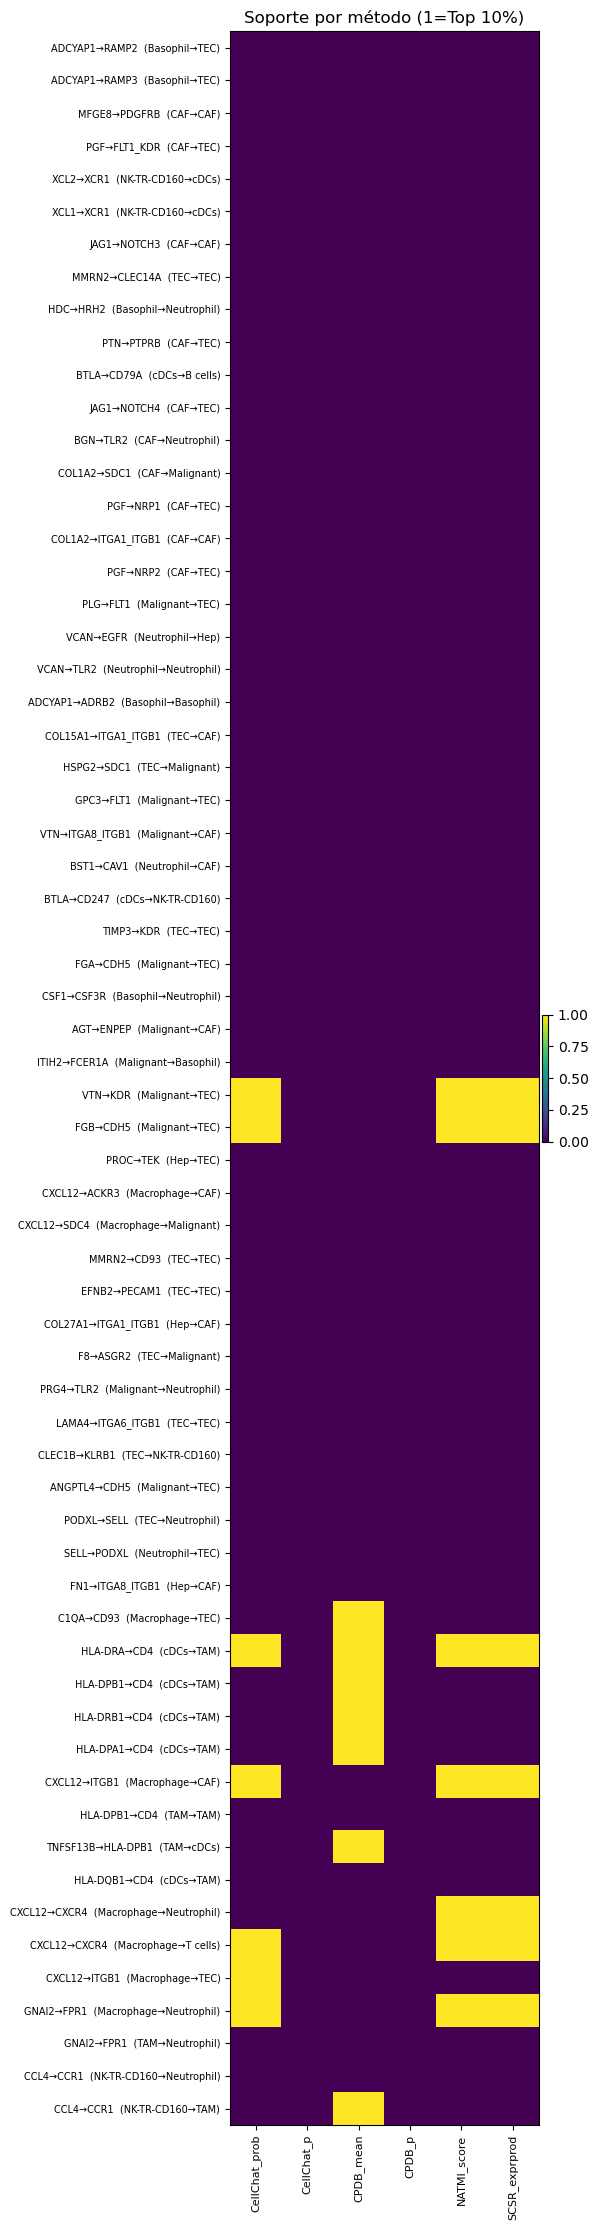

In [46]:
plot_lr_method_barcode(dff, q=0.10)

In [17]:
import numpy as np, pandas as pd

df = adata.uns['liana_res'].copy()

# columnas clave y tipos
for c in ['magnitude_rank','specificity_rank','ligand_props','receptor_props']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
assert {'source','target'}.issubset(df.columns)

print("Sources:", df['source'].nunique(), "Targets:", df['target'].nunique(), "Filas:", df.shape[0])
print(df[['magnitude_rank','specificity_rank']].describe())


Sources: 12 Targets: 12 Filas: 20659
       magnitude_rank  specificity_rank
count    2.065900e+04      20659.000000
mean     6.334315e-01          0.874856
std      4.344380e-01          0.258228
min      1.303660e-16          0.000436
25%      1.005734e-01          1.000000
50%      1.000000e+00          1.000000
75%      1.000000e+00          1.000000
max      1.000000e+00          1.000000


/tmp/ipykernel_1634992/2605520055.py:10: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead


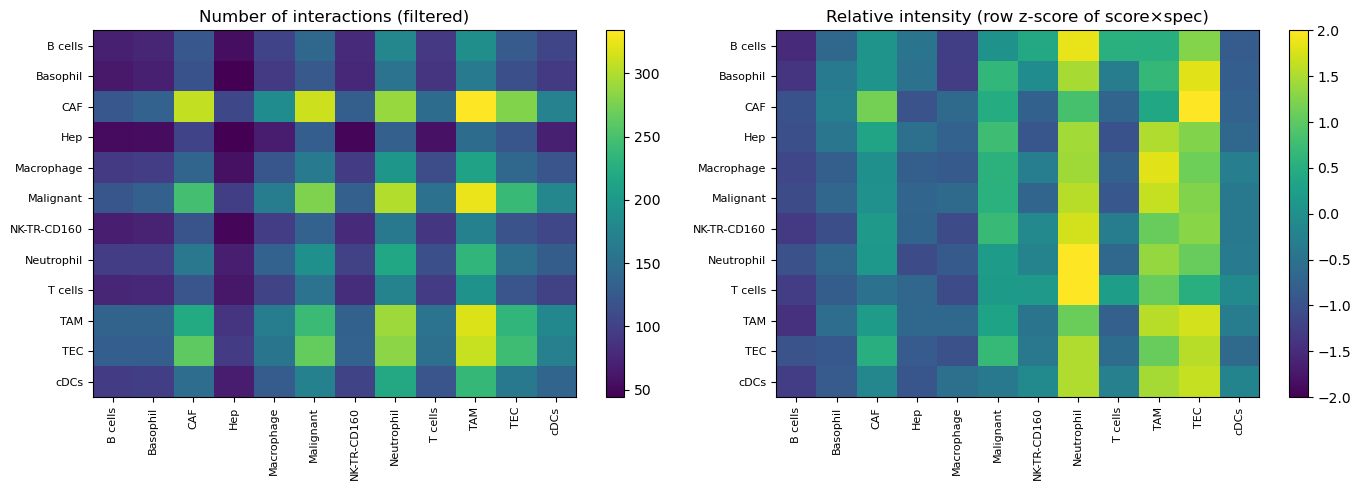

In [18]:
import matplotlib.pyplot as plt

# filtro base
dff = df[(df['ligand_props']>=0.10) & (df['receptor_props']>=0.10)].copy()
dff['score'] = 1 - dff['magnitude_rank']
dff['spec']  = 1 - dff['specificity_rank']
dff['w']     = dff['score']*dff['spec']

# universo de etiquetas
if pd.api.types.is_categorical_dtype(adata.obs['CellType_harmonized']):
    ct_all = list(adata.obs['CellType_harmonized'].cat.categories.astype(str))
else:
    ct_all = sorted(adata.obs['CellType_harmonized'].astype(str).unique())

# pivotes cuadrados
mat_counts = (dff.groupby(['source','target']).size()
                .unstack(fill_value=0)
                .reindex(index=ct_all, columns=ct_all, fill_value=0))

mat_sum = (dff.groupby(['source','target'])['w'].sum()
             .unstack(fill_value=0)
             .reindex(index=ct_all, columns=ct_all, fill_value=0))

# z-score por fila (patrón relativo por emisor)
row_mean = mat_sum.mean(axis=1).values[:,None]
row_std  = (mat_sum.std(axis=1).replace(0,np.nan).values[:,None])
mat_z = (mat_sum.values - row_mean) / (row_std + 1e-9)

fig, ax = plt.subplots(1,2, figsize=(14,5))
im0 = ax[0].imshow(mat_counts.values, aspect='auto'); ax[0].set_title('Number of interactions (filtered)')
ax[0].set_yticks(range(len(ct_all))); ax[0].set_yticklabels(ct_all, fontsize=8)
ax[0].set_xticks(range(len(ct_all))); ax[0].set_xticklabels(ct_all, rotation=90, fontsize=8); plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(mat_z, aspect='auto', vmin=-2, vmax=2); ax[1].set_title('Relative intensity (row z-score of score×spec)')
ax[1].set_yticks(range(len(ct_all))); ax[1].set_yticklabels(ct_all, fontsize=8)
ax[1].set_xticks(range(len(ct_all))); ax[1].set_xticklabels(ct_all, rotation=90, fontsize=8); plt.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()


In [19]:
import liana as li, matplotlib.pyplot as plt

dff = df[(df['ligand_props']>=0.10) & (df['receptor_props']>=0.10)].copy()
L = 'ligand_complex'  if 'ligand_complex'  in dff.columns else 'ligand'
R = 'receptor_complex' if 'receptor_complex' in dff.columns else 'receptor'
ct_all = present_tgt  # ya calculado arriba
sources_focus = ['Malignant cells','TAMs','TECs','Hepatocytes']
sources_focus = [s for s in sources_focus if s in present_tgt]

M_PER_TARGET = 3  # nº de L-R por target
def top_keys_per_target(d, s, targets, m=M_PER_TARGET):
    keys = set()
    for t in targets:
        sub = d[(d['source']==s) & (d['target']==t)]
        if sub.empty: continue
        sub = sub.sort_values(['magnitude_rank','specificity_rank'], ascending=[True,True]).head(m)
        keys |= set(map(tuple, sub[['source','target',L,R]].values))
    return keys

keysets = {s: top_keys_per_target(dff, s, ct_all) for s in sources_focus}
def make_filter(s):
    keys = keysets.get(s, set())
    return lambda r: (str(r.get('source',''))==s) and ((r['source'], r['target'], r.get(L,None), r.get(R,None)) in keys)

for s in sources_focus:
    for mode in ['counts','mean']:
        li.pl.circle_plot(
            adata=adata, groupby='CellType_harmonized',
            score_key='magnitude_rank', inverse_score=True,
            source_labels=[s], target_labels=ct_all,
            filter_fun=make_filter(s),
            pivot_mode=mode, mask_mode='and',
            figure_size=(8,8), uns_key='liana_res'
        )
        plt.savefig(f"/home/mdiaz/HCC_project/MERGED_analysis/figures/circle_all_{s}_{mode}.png", dpi=300, bbox_inches="tight"); plt.close()


In [20]:
# Top 10 global y por emisor
top_global = dff.sort_values(['magnitude_rank','specificity_rank'], ascending=[True,True]).head(50)
top_global.to_csv("RRA_top_global.csv", index=False)

tops = []
for s in ['Malignant cells','TAMs','TECs','Hepatocytes']:
    sub = (dff[dff['source']==s]
           .sort_values(['magnitude_rank','specificity_rank'], ascending=[True,True])
           .head(200))
    if not sub.empty: tops.append(sub.assign(source_focus=s))
pd.concat(tops).to_csv("/home/mdiaz/HCC_project/MERGED_analysis/figures/RRA_top_by_source.csv", index=False)
